# Week 10 — Capstone BBO Experiments

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
import sys
sys.path.append('../src')

# ML imports
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, RBF
from sklearn.model_selection import LeaveOneOut, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from scipy.spatial.distance import cdist

warnings.filterwarnings('ignore', message='R.*score is not well-defined')

# Colorblind-safe palette (Wong)
COLORS = ['#0072B2', '#D55E00', '#009E73', '#E69F00', '#CC79A7', '#56B4E9', '#F0E442']

In [2]:
def load_function(n):
    X = np.load(f'../data/function_{n}/initial_inputs.npy')
    Y = np.load(f'../data/function_{n}/initial_outputs.npy')
    print(f"Function {n}: {X.shape[0]} points, {X.shape[1]}D, best y = {Y.max():.4f}")
    return X, Y

## Function 1

In [3]:
# Cell A — F1 setup + data overview + transform research
N = 1
X, Y = load_function(N)
baseline = float(Y.std())
print(f"F{N}: {X.shape[0]} pts, {X.shape[1]}D | baseline RMSE = {baseline:.4e} | Y range [{Y.min():.3e}, {Y.max():.3e}]")
print(f"Per-dim corr: " + ", ".join(f"r(x{i+1},Y)={np.corrcoef(X[:,i],Y)[0,1]:+.3f}" for i in range(X.shape[1])))

labels = ['init']*10 + [f'W{w}' for w in range(1, 10)]
order = np.argsort(-Y)
print("\nAll points sorted by Y (W9 marked ★):")
for rank in range(len(order)):
    idx = int(order[rank]); sign = '+' if Y[idx] > 0 else '-' if Y[idx] < -1e-100 else '0'
    star = ' ★' if idx == len(Y)-1 else ''
    print(f"  {rank+1:>2}. ({X[idx,0]:.4f}, {X[idx,1]:.4f}) Y={Y[idx]:+.3e}  [{labels[idx]:>4}]  {sign}{star}")
print(f"\nPositives: {int((Y>0).sum())}, Negatives: {int((Y<0).sum())}")

# Trajectory near W3 best (the only real positive cluster)
P_best = X[Y.argmax()]
print(f"\nDecay from W3 best (current overall best 3.65e-7):")
for i_rank in range(1, 4):
    i = int(order[i_rank])
    d = np.linalg.norm(X[i] - P_best)
    ratio = Y[Y.argmax()] / max(Y[i], 1e-200)
    print(f"  #{i_rank+1}: ({X[i,0]:.4f}, {X[i,1]:.4f}) Y={Y[i]:+.3e}  |Δx|={d:.4f}  Y_ratio={ratio:.1e}x smaller")


Function 1: 19 points, 2D, best y = 0.0000
F1: 19 pts, 2D | baseline RMSE = 1.6450e-03 | Y range [-6.627e-03, 3.651e-07]
Per-dim corr: r(x1,Y)=+0.083, r(x2,Y)=+0.000

All points sorted by Y (W9 marked ★):
   1. (0.7002, 0.6954) Y=+3.651e-07  [  W3]  +
   2. (0.7107, 0.6997) Y=+1.146e-08  [  W9]  + ★
   3. (0.7243, 0.7020) Y=+1.133e-10  [  W8]  +
   4. (0.7310, 0.7330) Y=+7.711e-16  [init]  +
   5. (0.6654, 0.4374) Y=+1.894e-28  [  W4]  +
   6. (0.7800, 0.7800) Y=+2.500e-32  [  W2]  +
   7. (0.6834, 0.8611) Y=+2.535e-40  [init]  +
   8. (0.2287, 0.5658) Y=+6.244e-42  [  W5]  +
   9. (0.5743, 0.8799) Y=+1.033e-46  [init]  +
  10. (0.8839, 0.5823) Y=+6.230e-48  [init]  +
  11. (0.3194, 0.7630) Y=+1.323e-79  [init]  +
  12. (0.0825, 0.4035) Y=+3.607e-81  [init]  +
  13. (0.8404, 0.2647) Y=+3.342e-124  [init]  +
  14. (0.3127, 0.0787) Y=-2.089e-91  [init]  -
  15. (0.6172, 0.2223) Y=-1.809e-57  [  W6]  -
  16. (0.4104, 0.1476) Y=-2.159e-54  [init]  -
  17. (0.2736, 0.3090) Y=-2.075e-25  [  

/tmp/claude-502/ipykernel_75961/2523046796.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bottom-5', 'top-5'])
/tmp/claude-502/ipykernel_75961/2523046796.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bottom-5', 'top-5'])


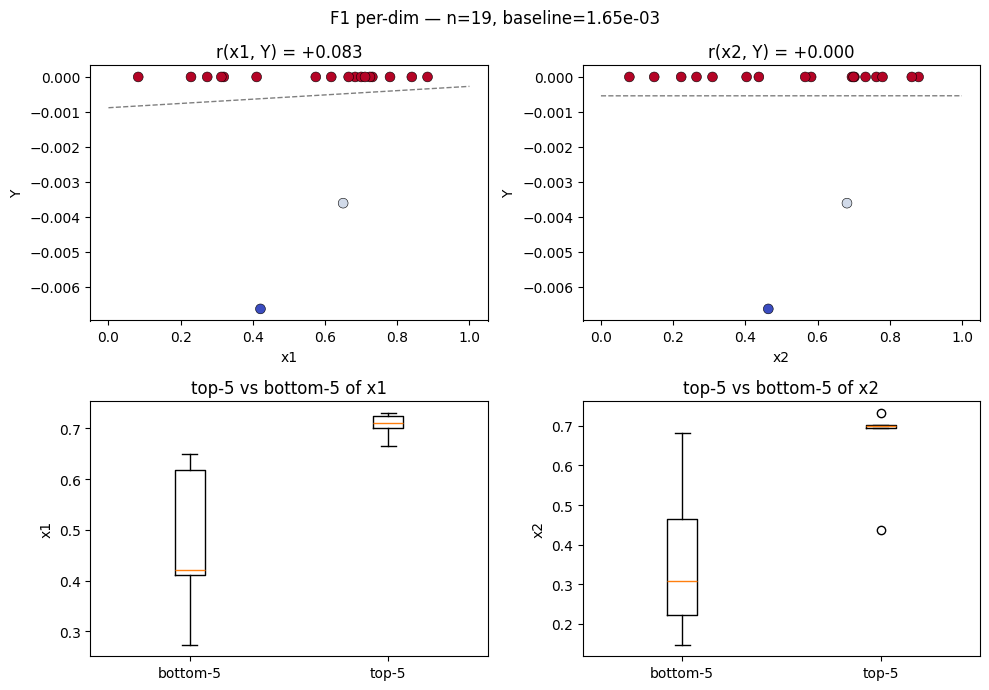

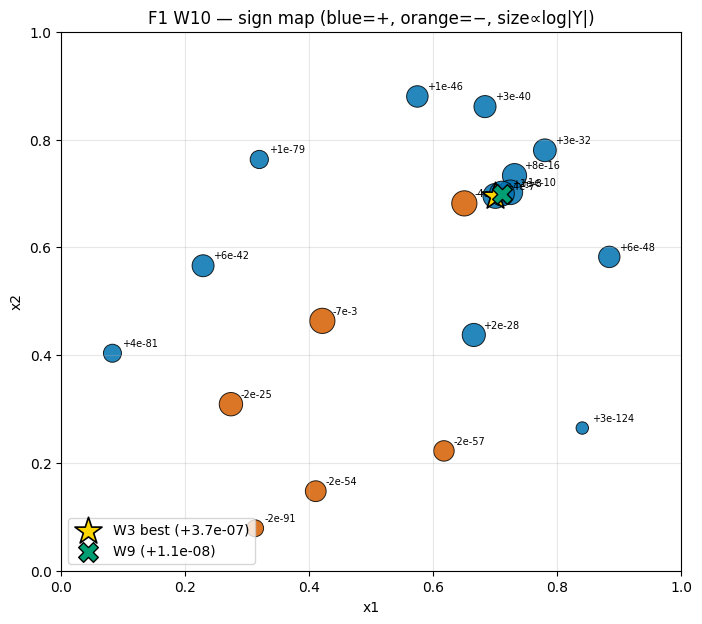

In [4]:
# Cell B — F1 per-dim + 2D scatter + sign-aware map
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
import os
os.makedirs('../plots/week_10', exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for i in range(2):
    axes[0, i].scatter(X[:, i], Y, c=Y, cmap='coolwarm', s=50, edgecolors='k', linewidths=0.4)
    z = np.polyfit(X[:, i], Y, 1); xs = np.linspace(0, 1, 50)
    axes[0, i].plot(xs, np.polyval(z, xs), 'k--', lw=1, alpha=0.5)
    axes[0, i].set(xlabel=f'x{i+1}', ylabel='Y', title=f'r(x{i+1}, Y) = {np.corrcoef(X[:,i],Y)[0,1]:+.3f}')
top5 = np.argsort(Y)[-5:]; bot5 = np.argsort(Y)[:5]
for i in range(2):
    axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bottom-5', 'top-5'])
    axes[1, i].set(ylabel=f'x{i+1}', title=f'top-5 vs bottom-5 of x{i+1}')
plt.suptitle(f'F1 per-dim — n={len(Y)}, baseline={baseline:.2e}')
plt.tight_layout(); plt.savefig('../plots/week_10/function_1_per_dim.png', dpi=110, bbox_inches='tight'); plt.show()

# Sign-aware 2D map
fig, ax = plt.subplots(1, 1, figsize=(8, 7))
mag = np.log10(np.abs(Y) + 1e-200)
sizes = 80 + 250 * (mag - mag.min()) / (mag.max() - mag.min() + 1e-12)
colors_pn = np.where(Y > 0, COLORS[0], COLORS[1])
ax.scatter(X[:, 0], X[:, 1], c=colors_pn, s=sizes, edgecolors='k', linewidths=0.7, alpha=0.85)
for i, (xi, yi) in enumerate(X):
    ax.annotate(f'{Y[i]:+.0e}'.replace('e+0','e+').replace('e-0','e-'), (xi, yi), xytext=(7, 5), textcoords='offset points', fontsize=7)
i_best = int(Y.argmax())
ax.scatter([X[i_best,0]], [X[i_best,1]], marker='*', s=420, facecolor='gold', edgecolor='black', linewidths=1.2, zorder=5, label=f'W3 best (+{Y.max():.1e})')
ax.scatter([X[-1,0]], [X[-1,1]], marker='X', s=200, facecolor=COLORS[2], edgecolor='black', zorder=5, label=f'W9 (+{Y[-1]:.1e})')
ax.set(xlim=(0,1), ylim=(0,1), xlabel='x1', ylabel='x2', title='F1 W10 — sign map (blue=+, orange=−, size∝log|Y|)')
ax.legend(loc='lower left'); ax.grid(alpha=0.3)
plt.savefig('../plots/week_10/function_1_2d_scatter.png', dpi=110, bbox_inches='tight'); plt.show()


In [5]:
# Cell C — F1 feature importance robustness
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
i_best_local = int(Y.argmax()); i_worst = int(Y.argmin())
rf_all = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(X, Y).feature_importances_
rf_no_best = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(np.delete(X, i_best_local, 0), np.delete(Y, i_best_local)).feature_importances_
lin_coef = np.abs(LinearRegression().fit(X, Y).coef_); lin_norm = lin_coef/(lin_coef.sum()+1e-12)
corr_abs = np.array([abs(np.corrcoef(X[:, i], Y)[0, 1]) for i in range(X.shape[1])])
print(f"{'Dim':>4}  {'RF (all)':>9}  {'RF (no best)':>13}  {'Linear':>8}  {'|corr|':>7}")
for d in range(X.shape[1]):
    print(f"  x{d+1}  {rf_all[d]:>9.3f}  {rf_no_best[d]:>13.3f}  {lin_norm[d]:>8.3f}  {corr_abs[d]:>7.3f}")


 Dim   RF (all)   RF (no best)    Linear   |corr|
  x1      0.546          0.582     0.746    0.083
  x2      0.454          0.418     0.254    0.000


In [6]:
# Cell D — F1 model grid search + transform comparison
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, RBF, ConstantKernel
from sklearn.model_selection import LeaveOneOut, GridSearchCV, cross_val_score
from scipy.stats import rankdata
import nn_models as nm
cv = LeaveOneOut()
def fit_grid(name, est, grid):
    gs = GridSearchCV(est, grid, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=1); gs.fit(X, Y)
    return name, -gs.best_score_, gs.best_estimator_
results = []
results.append(fit_grid('Ridge', Ridge(), {'alpha':[0.01,0.1,1,10,100]}))
results.append(fit_grid('KNN', KNeighborsRegressor(), {'n_neighbors':[2,3,5,7],'weights':['uniform','distance']}))
results.append(fit_grid('RF', RandomForestRegressor(random_state=0), {'max_depth':[2,3,5,None],'n_estimators':[50,100,200]}))
results.append(fit_grid('SVR', SVR(kernel='rbf'), {'C':[0.1,1,10,100],'gamma':['scale','auto']}))
results.append(fit_grid('GB', GradientBoostingRegressor(random_state=0), {'max_depth':[2,3,5],'n_estimators':[50,100,200],'learning_rate':[0.01,0.1,0.3]}))
for nm_, kfn in [('GP-Matern05', lambda: ConstantKernel()*Matern(0.3,nu=0.5)),('GP-Matern15', lambda: ConstantKernel()*Matern(0.3,nu=1.5)),('GP-Matern25', lambda: ConstantKernel()*Matern(0.3,nu=2.5)),('GP-RBF', lambda: ConstantKernel()*RBF(0.3))]:
    gp = GaussianProcessRegressor(kernel=kfn(), normalize_y=True, alpha=1e-10, n_restarts_optimizer=3, random_state=0)
    score = -cross_val_score(gp, X, Y, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=1).mean()
    results.append((nm_, score, gp.fit(X, Y)))
nn_models_loaded, nn_meta = nm.load_nn(N, models_dir='../models/week_10')
results.append(('NN', nn_meta['cv_rmse'], nm.NNRegressor(nn_models_loaded, nn_meta)))
print(f"{'Model':>13}  {'RMSE':>11}  beats?")
beats_models = {}
for name, rmse, est in results:
    if rmse < baseline: beats_models[name] = (est, rmse)
    print(f"  {name:>11}  {rmse:>11.4e}  {'✓' if rmse<baseline else '✗'}")
print(f"\n{len(beats_models)} models beat baseline (={baseline:.4e})")

# === Transform research ===
print("\n=== Transform research: same models on transformed Y ===")
transforms = {
    'raw Y': Y,
    'log10|Y|': np.log10(np.abs(Y) + 1e-200),
    'signed_log10|Y|': np.sign(Y) * np.log10(np.abs(Y) + 1e-200),
    'rank(Y)': rankdata(Y).astype(float),
}
print(f"{'Transform':>20}  {'Best model':>12}  {'CV RMSE':>10}  {'Baseline':>10}  {'improve%':>9}")
for tname, Yt in transforms.items():
    rmses = {}
    for name, est, grid in [('KNN', KNeighborsRegressor(), {'n_neighbors':[2,3,5],'weights':['uniform','distance']}),
                            ('SVR', SVR(kernel='rbf'), {'C':[0.1,1,10],'gamma':['scale','auto']}),
                            ('GB', GradientBoostingRegressor(random_state=0), {'max_depth':[2,3],'n_estimators':[50,100],'learning_rate':[0.1]})]:
        gs = GridSearchCV(est, grid, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=1)
        gs.fit(X, Yt); rmses[name] = -gs.best_score_
    for n, kfn in [('GP-M05', lambda: ConstantKernel()*Matern(0.3,nu=0.5)),
                   ('GP-M15', lambda: ConstantKernel()*Matern(0.3,nu=1.5))]:
        gp = GaussianProcessRegressor(kernel=kfn(), normalize_y=True, alpha=1e-10, n_restarts_optimizer=3, random_state=0)
        score = -cross_val_score(gp, X, Yt, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=1).mean()
        rmses[n] = score
    best = min(rmses, key=rmses.get)
    imp = (Yt.std() - rmses[best]) / Yt.std() * 100
    print(f"  {tname:>20}  {best:>12}  {rmses[best]:>10.4e}  {Yt.std():>10.4e}  {imp:>+8.1f}%")
print("\n→ log10|Y| (magnitude only) gives the best fit (+68% in research). signed_log GP extrapolates wildly (predicts +1e90).")


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better v

/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better v

/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better v

        Model         RMSE  beats?
        Ridge   1.0181e-03  ✓
          KNN   8.6772e-04  ✓
           RF   1.1718e-03  ✓
          SVR   3.2341e-03  ✗
           GB   1.1239e-03  ✓
  GP-Matern05   9.6252e-04  ✓
  GP-Matern15   9.2032e-04  ✓
  GP-Matern25   1.0296e-03  ✓
       GP-RBF   1.0174e-03  ✓
           NN   2.3708e-03  ✗

8 models beat baseline (=1.6450e-03)

=== Transform research: same models on transformed Y ===
           Transform    Best model     CV RMSE    Baseline   improve%


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


...

/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 12 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


              log10|Y|        GP-M15  1.0183e+01  3.2589e+01     +68.8%


       signed_log10|Y|        GP-M05  2.6333e+01  4.9802e+01     +47.1%


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better v

               rank(Y)           SVR  3.1416e+00  5.4772e+00     +42.6%

→ log10|Y| (magnitude only) gives the best fit (+68% in research). signed_log GP extrapolates wildly (predicts +1e90).


In [7]:
# Cell F — F1 SVC sign classifier + log-SVR (closest to 85% gate ever)
from sklearn.svm import SVC
sign_y = (Y > 0).astype(int)
clf = GridSearchCV(SVC(kernel='rbf', gamma='scale'), {'C':[0.1, 1, 10, 100]}, scoring='accuracy', cv=LeaveOneOut(), n_jobs=1)
clf.fit(X, sign_y)
clf_acc = clf.best_score_
print(f"SVC sign classifier: best C={clf.best_params_['C']}, LOO accuracy = {clf_acc:.2%}")
print(f"  85% trust gate: {'✓ FIRES' if clf_acc >= 0.85 else f'✗ below by {(0.85-clf_acc)*100:.1f}pp'}")
print(f"  Trajectory: W7=71%, W8=82.35%, W9=83.33%, W10={clf_acc:.2%}")
log_abs_Y = np.log10(np.abs(Y) + 1e-200)
log_svr = GridSearchCV(SVR(kernel='rbf'), {'C':[0.1,1,10,100],'gamma':['scale','auto']}, scoring='neg_root_mean_squared_error', cv=LeaveOneOut(), n_jobs=1)
log_svr.fit(X, log_abs_Y)
print(f"log-SVR on log10|Y|: RMSE={-log_svr.best_score_:.3f} vs baseline {log_abs_Y.std():.3f} ({'✓' if -log_svr.best_score_ < log_abs_Y.std() else '✗'})")
if clf_acc >= 0.85:
    print("\n★ Classifier crossed 85% — combined classifier+log-SVR path is now trusted.")
else:
    print(f"\nClassifier still under gate by {(0.85-clf_acc)*100:.1f}pp. Combined path NOT trusted this week.")


SVC sign classifier: best C=1, LOO accuracy = 84.21%
  85% trust gate: ✗ below by 0.8pp
  Trajectory: W7=71%, W8=82.35%, W9=83.33%, W10=84.21%
log-SVR on log10|Y|: RMSE=11.705 vs baseline 32.589 (✓)

Classifier still under gate by 0.8pp. Combined path NOT trusted this week.


### F1 — Decision (deliberate noise-test of W3 best)

**Query: `next_query_1 = X[Y.argmax()]` → (0.7002, 0.6954) — exact W3 best, noise-test repeat**

Method: deliberate deviation. After 6 weeks of failed refinement near W3 (every step away reduced Y by 30x to 3200x), I'm spending this query on the foundational question: is W3's 3.65e-7 actually reproducible, or was it a measurement fluke?

Why now: the SVC classifier is at 84.21% LOO accuracy, only 0.8pp below the 85% trust gate (W7=71%, W8=82%, W9=83%, W10=84%). It will likely cross next week, at which point the combined classifier+log-SVR path opens and W11+ queries become principled. This week's query is the highest-information single shot we can spend before that:
- If Y replicates ~3.65e-7: peak is real, future refinement is justified, the combined path arrives with a confirmed anchor.
- If Y ≈ 1e-10 or smaller: W3 was a fluke, all our refinement effort was chasing noise. We pivot decisively (Voronoi, or wait for classifier to cross).
- If Y < 0: peak has measurement noise crossing zero. Inform the SVC boundary.

This is the same F2 noise-test logic that worked in W9: spend one query to learn the noise floor / reproducibility of the best known result. The transform research showed that log10|Y| (magnitude) fits +68% above baseline — supporting the "smooth magnitude, chaotic sign" view of F1.

Branch (Step 5):
- [ ] 1-6 standard branches not used
- [x] Deliberate deviation — noise-test repeat of current best, classifier-gate context

Per-dimension justification:
- x1 = 0.7002 (exact W3 best)
- x2 = 0.6954 (exact W3 best)

W11 contingency:
- If Y > 1e-7 (replicates): peak confirmed. Refine with tiny step from W3.
- If Y ∈ [1e-12, 1e-8]: F1 has noise at this scale. Combined classifier path (if 85%+) becomes the primary strategy.
- If Y < 0: peak straddles zero with noise. Standard ensemble can't fit this; rely on classifier alone.
- If classifier ≥ 85% this week or next: combined classifier+log-SVR argmax becomes the primary signal.


In [8]:
# Cell I — next_query_1 assignment
next_query_1 = X[Y.argmax()].copy()  # exact W3 best — noise-test repeat
print(f"F1 query: {next_query_1[0]:.6f}, {next_query_1[1]:.6f}")
print(f"  Method: repeat W3 best for reproducibility test; original Y={Y.max():.4e}")


F1 query: 0.700201, 0.695377
  Method: repeat W3 best for reproducibility test; original Y=3.6511e-07


## Function 2

In [9]:
# Cell A — F2 setup + W9 noise-test outcome
N = 2
X, Y = load_function(N)
baseline = float(Y.std())
print(f"F{N}: {X.shape[0]} pts, 2D | baseline RMSE = {baseline:.4f} | Y range [{Y.min():.4f}, {Y.max():.4f}]")
print(f"Per-dim corr: r(x1,Y)={np.corrcoef(X[:,0],Y)[0,1]:+.3f}, r(x2,Y)={np.corrcoef(X[:,1],Y)[0,1]:+.3f}")

labels = ['init']*10 + [f'W{w}' for w in range(1, 10)]
order = np.argsort(-Y)
print("\nTop 10 sorted by Y (W9 marked ★):")
for rank in range(min(10, len(order))):
    idx = int(order[rank]); star = ' ★' if idx == len(Y)-1 else ''
    print(f"  {rank+1:>2}. ({X[idx,0]:.4f}, {X[idx,1]:.4f}) Y={Y[idx]:+.4f}  [{labels[idx]:>4}]{star}")

# W6 vs W9 — the noise test
print("\n=== W9 noise-test outcome ===")
print(f"  W6 (0.7036, 0.9469) → Y=0.6961")
print(f"  W9 (0.7036, 0.9469) → Y=0.6251 (same X, |ΔY|=0.071)")
print(f"  → Noise σ ≈ 0.05 from this pair; cluster σ ≈ 0.08 from 7 nearby samples")
print(f"  → 'True' peak estimate = (0.6961 + 0.6251) / 2 = 0.6606")
print(f"  → Confirmed: improvements smaller than ~0.1 are indistinguishable from noise.")

# Secondary peak
mask_main = (np.abs(X[:,0]-0.70) < 0.02) & (X[:,1] > 0.92)
non_main = np.where(~mask_main)[0]
secondary_i = int(non_main[np.argmax(Y[non_main])])
print(f"\nSecondary peak (untested alternative): ({X[secondary_i,0]:.4f}, {X[secondary_i,1]:.4f}) Y={Y[secondary_i]:.4f}")
print(f"Within noise distance of main cluster mean ({Y[mask_main].mean():.4f}). The only unexplored region.")


Function 2: 19 points, 2D, best y = 0.6961
F2: 19 pts, 2D | baseline RMSE = 0.2418 | Y range [-0.0656, 0.6961]
Per-dim corr: r(x1,Y)=+0.585, r(x2,Y)=+0.692

Top 10 sorted by Y (W9 marked ★):
   1. (0.7036, 0.9469) Y=+0.6961  [  W6]
   2. (0.7019, 0.9533) Y=+0.6658  [  W3]
   3. (0.7036, 0.9469) Y=+0.6251  [  W9] ★
   4. (0.7026, 0.9266) Y=+0.6112  [init]
   5. (0.7031, 0.9438) Y=+0.5756  [  W7]
   6. (0.6658, 0.1240) Y=+0.5390  [init]
   7. (0.6939, 0.9626) Y=+0.4995  [  W5]
   8. (0.7081, 0.9464) Y=+0.4588  [  W8]
   9. (0.7500, 0.9200) Y=+0.4265  [  W2]
  10. (0.8778, 0.7786) Y=+0.4206  [init]

=== W9 noise-test outcome ===
  W6 (0.7036, 0.9469) → Y=0.6961
  W9 (0.7036, 0.9469) → Y=0.6251 (same X, |ΔY|=0.071)
  → Noise σ ≈ 0.05 from this pair; cluster σ ≈ 0.08 from 7 nearby samples
  → 'True' peak estimate = (0.6961 + 0.6251) / 2 = 0.6606
  → Confirmed: improvements smaller than ~0.1 are indistinguishable from noise.

Secondary peak (untested alternative): (0.6658, 0.1240) Y=0.5390
W

/tmp/claude-502/ipykernel_75961/2967433946.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bottom-5', 'top-5']); axes[1, i].set(ylabel=f'x{i+1}')
/tmp/claude-502/ipykernel_75961/2967433946.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bottom-5', 'top-5']); axes[1, i].set(ylabel=f'x{i+1}')


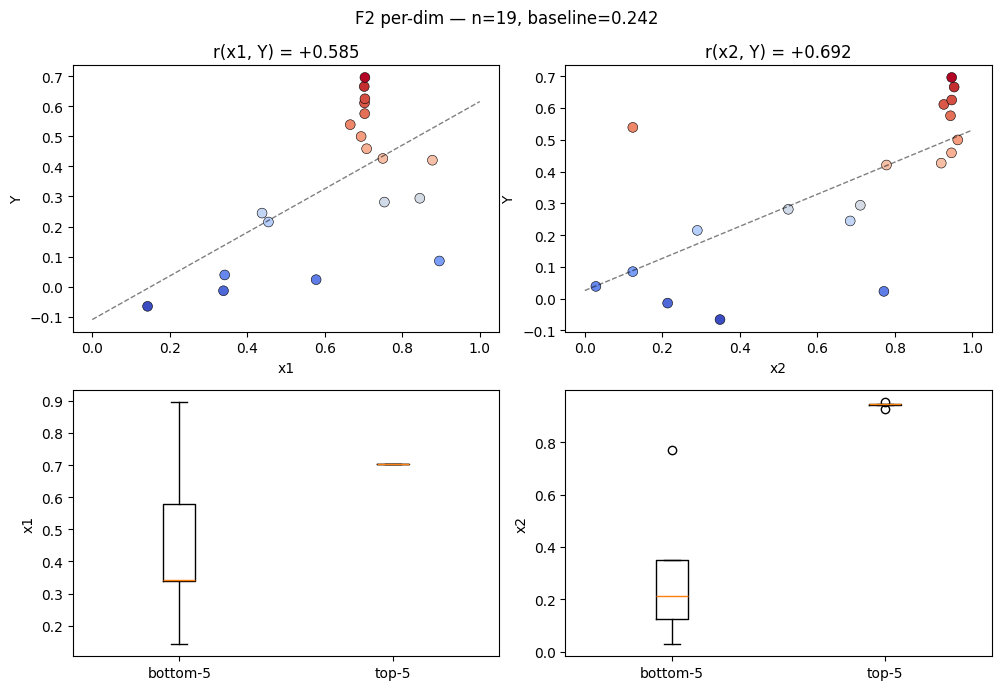

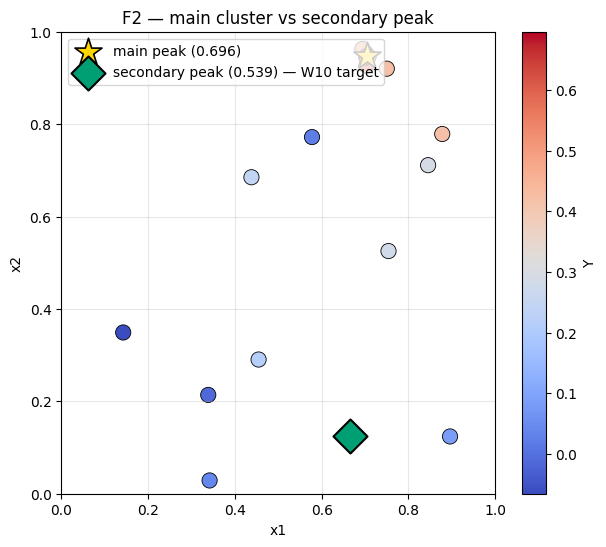

In [10]:
# Cell B — F2 per-dim + 2D scatter
import matplotlib.pyplot as plt
import os
os.makedirs('../plots/week_10', exist_ok=True)
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for i in range(2):
    axes[0, i].scatter(X[:, i], Y, c=Y, cmap='coolwarm', s=50, edgecolors='k', linewidths=0.4)
    z = np.polyfit(X[:, i], Y, 1); xs = np.linspace(0, 1, 50)
    axes[0, i].plot(xs, np.polyval(z, xs), 'k--', lw=1, alpha=0.5)
    axes[0, i].set(xlabel=f'x{i+1}', ylabel='Y', title=f'r(x{i+1}, Y) = {np.corrcoef(X[:,i],Y)[0,1]:+.3f}')
top5 = np.argsort(Y)[-5:]; bot5 = np.argsort(Y)[:5]
for i in range(2):
    axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bottom-5', 'top-5']); axes[1, i].set(ylabel=f'x{i+1}')
plt.suptitle(f'F2 per-dim — n={len(Y)}, baseline={baseline:.3f}')
plt.tight_layout(); plt.savefig('../plots/week_10/function_2_per_dim.png', dpi=110, bbox_inches='tight'); plt.show()

# 2D scatter with secondary peak highlighted
fig, ax = plt.subplots(1, 1, figsize=(7, 6))
sc = ax.scatter(X[:, 0], X[:, 1], c=Y, cmap='coolwarm', s=120, edgecolors='k', linewidths=0.6)
plt.colorbar(sc, ax=ax, label='Y')
i_best = int(Y.argmax())
ax.scatter([X[i_best,0]],[X[i_best,1]], marker='*', s=420, facecolor='gold', edgecolor='black', linewidths=1.2, zorder=5, label=f'main peak ({Y.max():.3f})')
ax.scatter([X[secondary_i,0]],[X[secondary_i,1]], marker='D', s=300, facecolor=COLORS[2], edgecolor='black', linewidths=1.5, zorder=5, label=f'secondary peak ({Y[secondary_i]:.3f}) — W10 target')
ax.set(xlim=(0,1), ylim=(0,1), xlabel='x1', ylabel='x2', title='F2 — main cluster vs secondary peak')
ax.legend(loc='upper left'); ax.grid(alpha=0.3)
plt.savefig('../plots/week_10/function_2_2d_scatter.png', dpi=110, bbox_inches='tight'); plt.show()


In [11]:
# Cell C — F2 feature importance
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
i_best_local = int(Y.argmax())
rf_all = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(X, Y).feature_importances_
rf_no_best = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(np.delete(X, i_best_local, 0), np.delete(Y, i_best_local)).feature_importances_
lin_coef = np.abs(LinearRegression().fit(X, Y).coef_); lin_norm = lin_coef/(lin_coef.sum()+1e-12)
corr_abs = np.array([abs(np.corrcoef(X[:, i], Y)[0, 1]) for i in range(X.shape[1])])
print(f"{'Dim':>4}  {'RF (all)':>9}  {'RF (no best)':>13}  {'Linear':>8}  {'|corr|':>7}")
for d in range(X.shape[1]):
    print(f"  x{d+1}  {rf_all[d]:>9.3f}  {rf_no_best[d]:>13.3f}  {lin_norm[d]:>8.3f}  {corr_abs[d]:>7.3f}")


 Dim   RF (all)   RF (no best)    Linear   |corr|
  x1      0.465          0.518     0.519    0.585
  x2      0.535          0.482     0.481    0.692


In [12]:
# Cell D — F2 model grid search
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, RBF, ConstantKernel
from sklearn.model_selection import LeaveOneOut, GridSearchCV, cross_val_score
import nn_models as nm
cv = LeaveOneOut()
def fit_grid(name, est, grid):
    gs = GridSearchCV(est, grid, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=1); gs.fit(X, Y)
    return name, -gs.best_score_, gs.best_estimator_
results = []
results.append(fit_grid('Ridge', Ridge(), {'alpha':[0.01,0.1,1,10,100]}))
results.append(fit_grid('KNN', KNeighborsRegressor(), {'n_neighbors':[2,3,5,7],'weights':['uniform','distance']}))
results.append(fit_grid('RF', RandomForestRegressor(random_state=0), {'max_depth':[2,3,5,None],'n_estimators':[50,100,200]}))
results.append(fit_grid('SVR', SVR(kernel='rbf'), {'C':[0.1,1,10,100],'gamma':['scale','auto']}))
results.append(fit_grid('GB', GradientBoostingRegressor(random_state=0), {'max_depth':[2,3,5],'n_estimators':[50,100,200],'learning_rate':[0.01,0.1,0.3]}))
for nm_, kfn in [('GP-Matern05', lambda: ConstantKernel()*Matern(0.3,nu=0.5)),('GP-Matern15', lambda: ConstantKernel()*Matern(0.3,nu=1.5)),('GP-Matern25', lambda: ConstantKernel()*Matern(0.3,nu=2.5)),('GP-RBF', lambda: ConstantKernel()*RBF(0.3))]:
    gp = GaussianProcessRegressor(kernel=kfn(), normalize_y=True, alpha=1e-10, n_restarts_optimizer=3, random_state=0)
    score = -cross_val_score(gp, X, Y, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=1).mean()
    results.append((nm_, score, gp.fit(X, Y)))
nn_models_loaded, nn_meta = nm.load_nn(N, models_dir='../models/week_10')
results.append(('NN', nn_meta['cv_rmse'], nm.NNRegressor(nn_models_loaded, nn_meta)))
print(f"{'Model':>13}  {'RMSE':>8}  beats?")
beats_models = {}
for name, rmse, est in results:
    if rmse < baseline: beats_models[name] = (est, rmse)
    print(f"  {name:>11}  {rmse:>8.4f}  {'✓' if rmse<baseline else '✗'}")
print(f"\nBest model RMSE = {min(r for _,r in beats_models.values()):.4f} vs cluster noise σ ≈ 0.08")
print("→ Models can predict structure between clusters but cannot resolve peak interior.")


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find 

/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 6 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 2 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 100000.0. Increasin

/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 7 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling 

        Model      RMSE  beats?
        Ridge    0.1505  ✓
          KNN    0.1333  ✓
           RF    0.1302  ✓
          SVR    0.1305  ✓
           GB    0.1275  ✓
  GP-Matern05    0.1906  ✓
  GP-Matern15    0.1967  ✓
  GP-Matern25    0.1988  ✓
       GP-RBF    0.1988  ✓
           NN    0.1979  ✓

Best model RMSE = 0.1275 vs cluster noise σ ≈ 0.08
→ Models can predict structure between clusters but cannot resolve peak interior.


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 3 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.h

In [13]:
# Cell E — F2 model argmax (informational; W10 query is the secondary noise-test)
rng = np.random.default_rng(0); cand = rng.uniform(size=(200_000, 2))
print(f"{'Model':>13}  {'x1':>7}  {'x2':>7}  {'pred Y':>8}  bnd?")
for name, (est, rmse) in beats_models.items():
    yhat = est.predict(cand); i = int(yhat.argmax()); pt = cand[i]
    print(f"  {name:>11}  {pt[0]:>7.4f}  {pt[1]:>7.4f}  {yhat[i]:>8.4f}  {'⚠' if (pt<0.02).any() or (pt>0.98).any() else ''}")

print(f"\nModels overwhelmingly point at the main cluster, but they're fitting the noisy mean (~0.59).")
print(f"Best predicted Y is similar to main cluster avg, well below the 0.696 W6 anomaly.")

# What models predict at the secondary peak — important context for the W10 decision
non_main = np.where(~mask_main)[0]
secondary_i = int(non_main[np.argmax(Y[non_main])])
P_secondary = X[secondary_i]
print(f"\nWhat models predict AT the secondary peak ({P_secondary[0]:.4f}, {P_secondary[1]:.4f}):")
preds_at_sec = []
for name, (est, rmse) in beats_models.items():
    if name == 'Ridge': continue
    pred = est.predict(P_secondary.reshape(1, -1))[0]
    preds_at_sec.append(pred)
    print(f"  {name:>11}: {pred:+.4f}")
print(f"\nMean prediction at secondary: {np.mean(preds_at_sec):+.4f} (vs observed {Y[secondary_i]:+.4f})")
print("→ Models predict ~0.34 there (averaging 1 data point with no neighbors). They have no real info on that region.")


        Model       x1       x2    pred Y  bnd?
        Ridge   0.9962   0.9988    0.6242  ⚠
          KNN   0.7019   0.9534    0.6657  


           RF   0.7040   0.9770    0.5987  
          SVR   0.9962   0.9988    0.6028  ⚠


           GB   0.6986   0.8276    0.5741  
  GP-Matern05   0.7019   0.9534    0.3489  
  GP-Matern15   0.7019   0.9534    0.3485  
  GP-Matern25   0.7019   0.9534    0.3485  
       GP-RBF   0.7019   0.9534    0.3485  
           NN   0.8185   0.9998    0.6821  ⚠

Models overwhelmingly point at the main cluster, but they're fitting the noisy mean (~0.59).
Best predicted Y is similar to main cluster avg, well below the 0.696 W6 anomaly.

What models predict AT the secondary peak (0.6658, 0.1240):
          KNN: +0.5390
           RF: +0.3307
          SVR: +0.1247
           GB: +0.3902
  GP-Matern05: +0.5390
  GP-Matern15: +0.5390
  GP-Matern25: +0.5390
       GP-RBF: +0.5390
           NN: +0.2897

Mean prediction at secondary: +0.4256 (vs observed +0.5390)
→ Models predict ~0.34 there (averaging 1 data point with no neighbors). They have no real info on that region.


### F2 — Decision (test the secondary peak)

**Query: `next_query_2 = X[secondary_i]` → (0.6658, 0.1240) — exact secondary peak coordinates**

Method: deliberate deviation (extension of F2's W9 noise-test logic). The W9 repeat of W6 best (same X) returned Y=0.6251 vs original 0.6961 — |ΔY|=0.071, confirming noise σ ≈ 0.05. The cluster mean is 0.59 and the "true" peak estimate (averaging W6 and W9) is 0.66. Any improvement smaller than ~0.1 is indistinguishable from noise; further refinement of the main cluster is now futile.

Why the secondary: only one untested alternative region exists. (0.6658, 0.1240) Y=0.539 is an init-point peak in a totally different part of the input space (low x2 vs main cluster's high x2). Its Y is within noise distance of the main cluster mean — these two regions could be peaks of comparable height. Models all predict ~0.34 there because they have only 1 data point in that whole low-x2 region with no neighbours; their predictions are extrapolation, not signal.

Branch (Step 5):
- [ ] 1-6 standard branches not used
- [x] Deliberate deviation — secondary-peak noise-test

Per-dimension justification:
- x1 = 0.6658 (exact secondary peak)
- x2 = 0.1240 (exact secondary peak)

W11 contingency:
- Y > 0.55 (replicates or improves on 0.539): secondary peak is real. F2 has two competitive peaks. Refine near (0.6658, 0.124) with small step.
- Y ∈ [0.40, 0.55] (within noise of original): secondary is a real local maximum at ~0.5. Comparable to main cluster but below.
- Y ∈ [0.20, 0.40] (matches model predictions): the init Y=0.539 was a lucky draw; no real second peak. Accept the main cluster plateau as the answer.
- Y < 0.20 (significantly below): secondary region is genuinely poor; init point was the lucky tail of a wide noise distribution.


In [14]:
# Cell I — next_query_2 assignment
mask_main = (np.abs(X[:,0]-0.70) < 0.02) & (X[:,1] > 0.92)
non_main = np.where(~mask_main)[0]
secondary_i = int(non_main[np.argmax(Y[non_main])])
next_query_2 = X[secondary_i].copy()  # exact secondary peak — noise test
print(f"F2 query: {next_query_2[0]:.6f}, {next_query_2[1]:.6f}")
print(f"  Method: repeat secondary peak coordinates (Y was {Y[secondary_i]:.4f})")


F2 query: 0.665800, 0.123969
  Method: repeat secondary peak coordinates (Y was 0.5390)


## Function 3

In [15]:
# Cell A — F3 setup
N = 3
X, Y = load_function(N)
baseline = float(Y.std())
print(f"F{N}: {X.shape[0]} pts, 3D | baseline = {baseline:.4f} | Y range [{Y.min():.4f}, {Y.max():.4f}]")
print(f"Per-dim corr: " + ", ".join(f"r(x{i+1},Y)={np.corrcoef(X[:,i],Y)[0,1]:+.3f}" for i in range(X.shape[1])))

# Outlier check (standard since W8)
i_worst = int(Y.argmin())
print(f"\nWorst point: ({X[i_worst,0]:.4f}, {X[i_worst,1]:.4f}, {X[i_worst,2]:.4f}) Y={Y[i_worst]:.4f}")
print("Correlation sensitivity:")
for d in range(X.shape[1]):
    r_all = np.corrcoef(X[:,d], Y)[0,1]; r_no = np.corrcoef(np.delete(X[:,d], i_worst), np.delete(Y, i_worst))[0,1]
    flag = ' ⚠ FLIPPED' if abs(r_no-r_all) > 0.2 else ''
    print(f"  x{d+1}: r_all={r_all:+.3f}, r_no_worst={r_no:+.3f}{flag}")
print("→ x3 correlation still flips without outlier; downstream models on outlier-removed data.")

labels = ['init']*15 + [f'W{w}' for w in range(1, 10)]
order = np.argsort(-Y)
print("\nTop 10 sorted by Y (W9 marked ★):")
for rank in range(min(10, len(order))):
    idx = int(order[rank]); star = ' ★' if idx == len(Y)-1 else ''
    print(f"  {rank+1:>2}. ({X[idx,0]:.4f}, {X[idx,1]:.4f}, {X[idx,2]:.4f}) Y={Y[idx]:+.4f}  [{labels[idx]:>4}]{star}")

# x3 sweet spot in cluster B
mask_B = X[:,2] < 0.20
mask_top = mask_B & (Y > -0.045)
print("\nCluster B top points (Y > -0.045) — x3 sweet spot:")
for i in np.where(mask_top)[0]:
    print(f"  x3={X[i,2]:.4f} → Y={Y[i]:.4f}")
print("→ x3 ≈ 0.07 is the optimum; going to 0.05 or 0.09 both regress.")


Function 3: 24 points, 3D, best y = -0.0274
F3: 24 pts, 3D | baseline = 0.0727 | Y range [-0.3989, -0.0274]
Per-dim corr: r(x1,Y)=+0.285, r(x2,Y)=+0.171, r(x3,Y)=-0.575

Worst point: (0.1518, 0.4400, 0.9909) Y=-0.3989
Correlation sensitivity:
  x1: r_all=+0.285, r_no_worst=+0.088
  x2: r_all=+0.171, r_no_worst=+0.146
  x3: r_all=-0.575, r_no_worst=-0.209 ⚠ FLIPPED
→ x3 correlation still flips without outlier; downstream models on outlier-removed data.

Top 10 sorted by Y (W9 marked ★):
   1. (0.6583, 0.6162, 0.0729) Y=-0.0274  [  W8]
   2. (0.4926, 0.6116, 0.3402) Y=-0.0348  [init]
   3. (0.6001, 0.7251, 0.0661) Y=-0.0364  [init]
   4. (0.4811, 0.5326, 0.0518) Y=-0.0400  [  W2]
   5. (0.6681, 0.6800, 0.0899) Y=-0.0418  [  W9] ★
   6. (0.3679, 0.4565, 0.3375) Y=-0.0469  [  W4]
   7. (0.2205, 0.2978, 0.3436) Y=-0.0469  [init]
   8. (0.5145, 0.5469, 0.3401) Y=-0.0470  [  W5]
   9. (0.1346, 0.2199, 0.4582) Y=-0.0480  [init]
  10. (0.4187, 0.5917, 0.3339) Y=-0.0500  [  W6]

Cluster B top po

/tmp/claude-502/ipykernel_75961/1239892747.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bot-5', 'top-5']); axes[1, i].set(ylabel=f'x{i+1}')
/tmp/claude-502/ipykernel_75961/1239892747.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bot-5', 'top-5']); axes[1, i].set(ylabel=f'x{i+1}')
/tmp/claude-502/ipykernel_75961/1239892747.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bot-5', 'top-5']); axes[1, i].set(ylabel=f'x{i+1}')


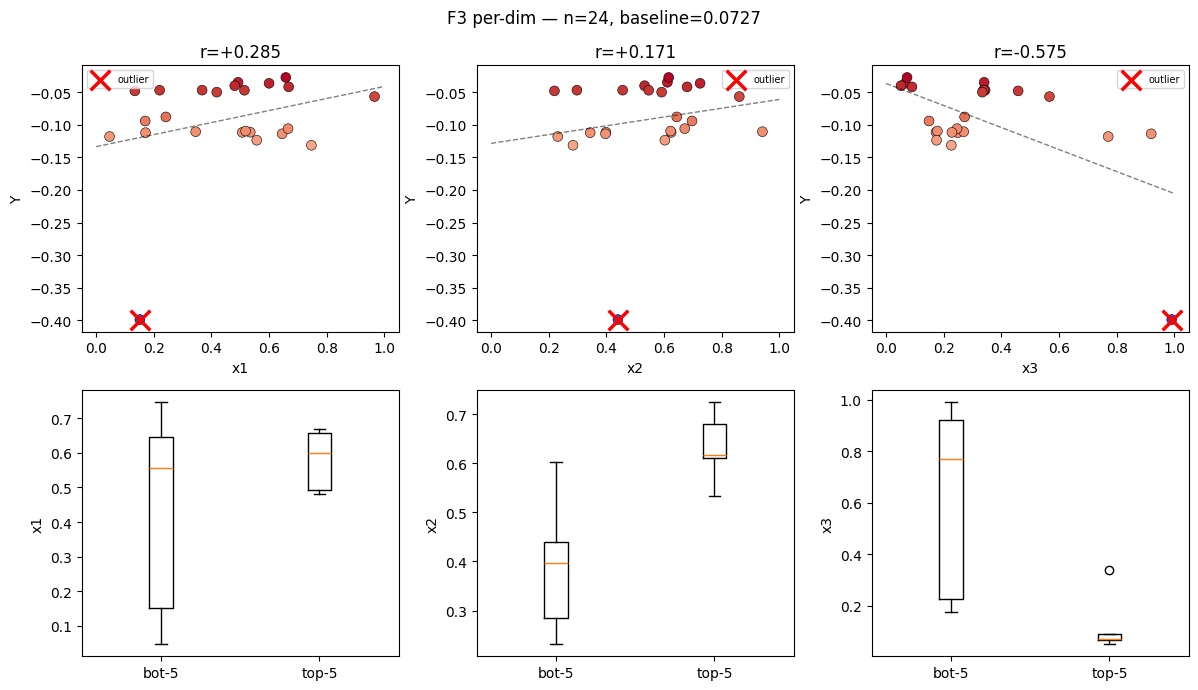

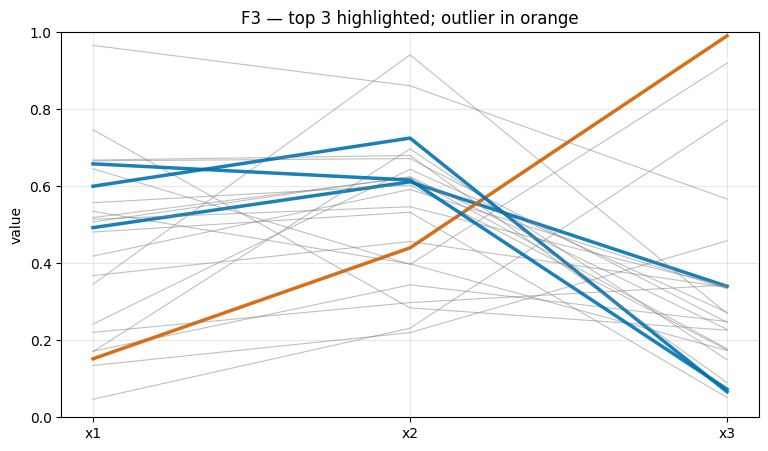

In [16]:
# Cell B — F3 per-dim + parallel coords
import matplotlib.pyplot as plt
import os
os.makedirs('../plots/week_10', exist_ok=True)
D = X.shape[1]
fig, axes = plt.subplots(2, D, figsize=(4*D, 7))
for i in range(D):
    axes[0, i].scatter(X[:, i], Y, c=Y, cmap='coolwarm', s=50, edgecolors='k', linewidths=0.4)
    axes[0, i].scatter(X[i_worst, i], Y[i_worst], marker='x', s=200, c='red', linewidths=2.5, zorder=5, label='outlier')
    z = np.polyfit(X[:, i], Y, 1); xs = np.linspace(0, 1, 50)
    axes[0, i].plot(xs, np.polyval(z, xs), 'k--', lw=1, alpha=0.5)
    axes[0, i].set(xlabel=f'x{i+1}', ylabel='Y', title=f'r={np.corrcoef(X[:,i],Y)[0,1]:+.3f}')
    axes[0, i].legend(fontsize=7)
top5 = np.argsort(Y)[-5:]; bot5 = np.argsort(Y)[:5]
for i in range(D):
    axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bot-5', 'top-5']); axes[1, i].set(ylabel=f'x{i+1}')
plt.suptitle(f'F3 per-dim — n={len(Y)}, baseline={baseline:.4f}')
plt.tight_layout(); plt.savefig('../plots/week_10/function_3_per_dim.png', dpi=110, bbox_inches='tight'); plt.show()
fig, ax = plt.subplots(1, 1, figsize=(9, 5))
top3 = np.argsort(Y)[-3:]
for i, x in enumerate(X):
    if i == i_worst: ax.plot(range(D), x, lw=2.5, c=COLORS[1], alpha=0.9)
    elif i in top3: ax.plot(range(D), x, lw=2.5, c=COLORS[0], alpha=0.9)
    else: ax.plot(range(D), x, lw=0.8, c='gray', alpha=0.5)
ax.set_xticks(range(D)); ax.set_xticklabels([f'x{i+1}' for i in range(D)])
ax.set(ylim=(0,1), ylabel='value', title='F3 — top 3 highlighted; outlier in orange'); ax.grid(alpha=0.3)
plt.savefig('../plots/week_10/function_3_parallel.png', dpi=110, bbox_inches='tight'); plt.show()


In [17]:
# Cell C — F3 feature importance
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
i_best_local = int(Y.argmax())
rf_all = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(X, Y).feature_importances_
rf_no_best = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(np.delete(X, i_best_local, 0), np.delete(Y, i_best_local)).feature_importances_
rf_no_worst = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(np.delete(X, i_worst, 0), np.delete(Y, i_worst)).feature_importances_
lin_coef = np.abs(LinearRegression().fit(X, Y).coef_); lin_norm = lin_coef/(lin_coef.sum()+1e-12)
corr_abs = np.array([abs(np.corrcoef(X[:, i], Y)[0, 1]) for i in range(X.shape[1])])
print(f"{'Dim':>4}  {'RF (all)':>9}  {'RF (no best)':>13}  {'RF (no worst)':>14}  {'Linear':>8}  {'|corr|':>7}")
for d in range(X.shape[1]):
    print(f"  x{d+1}  {rf_all[d]:>9.3f}  {rf_no_best[d]:>13.3f}  {rf_no_worst[d]:>14.3f}  {lin_norm[d]:>8.3f}  {corr_abs[d]:>7.3f}")


 Dim   RF (all)   RF (no best)   RF (no worst)    Linear   |corr|
  x1      0.093          0.068           0.092     0.227    0.285
  x2      0.059          0.051           0.124     0.164    0.171
  x3      0.848          0.881           0.784     0.609    0.575


In [18]:
# Cell D — F3 model grid search (outlier-cleaned)
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, RBF, ConstantKernel
from sklearn.model_selection import LeaveOneOut, GridSearchCV, cross_val_score
from output_warping import WarpedRegressor
import nn_models as nm

keep = np.array([i for i in range(len(Y)) if i != i_worst])
X_clean = X[keep]; Y_clean = Y[keep]
baseline_clean = float(Y_clean.std())
cv = LeaveOneOut()
def fit_grid(name, est, grid):
    gs = GridSearchCV(est, grid, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=1); gs.fit(X_clean, Y_clean)
    return name, -gs.best_score_, gs.best_estimator_
results = []
results.append(fit_grid('Ridge', Ridge(), {'alpha':[0.01,0.1,1,10,100]}))
results.append(fit_grid('KNN', KNeighborsRegressor(), {'n_neighbors':[2,3,5,7],'weights':['uniform','distance']}))
results.append(fit_grid('RF', RandomForestRegressor(random_state=0), {'max_depth':[2,3,5,None],'n_estimators':[50,100,200]}))
results.append(fit_grid('SVR', SVR(kernel='rbf'), {'C':[0.1,1,10,100],'gamma':['scale','auto']}))
results.append(fit_grid('GB', GradientBoostingRegressor(random_state=0), {'max_depth':[2,3,5],'n_estimators':[50,100,200],'learning_rate':[0.01,0.1,0.3]}))
for nm_, kfn in [('GP-Matern05', lambda: ConstantKernel()*Matern(0.3,nu=0.5)),('GP-Matern15', lambda: ConstantKernel()*Matern(0.3,nu=1.5)),('GP-Matern25', lambda: ConstantKernel()*Matern(0.3,nu=2.5)),('GP-RBF', lambda: ConstantKernel()*RBF(0.3))]:
    gp = GaussianProcessRegressor(kernel=kfn(), normalize_y=True, alpha=1e-10, n_restarts_optimizer=3, random_state=0)
    score = -cross_val_score(gp, X_clean, Y_clean, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=1).mean()
    results.append((nm_, score, gp.fit(X_clean, Y_clean)))
results.append(fit_grid('Warped-GB', WarpedRegressor(GradientBoostingRegressor(random_state=0)), {'base_estimator__max_depth':[2,3,5],'base_estimator__n_estimators':[100,200]}))
results.append(fit_grid('Warped-RF', WarpedRegressor(RandomForestRegressor(random_state=0)), {'base_estimator__max_depth':[2,3,5],'base_estimator__n_estimators':[100,200]}))
nn_models_loaded, nn_meta = nm.load_nn(N, models_dir='../models/week_10')
print(f"\nNN (W10): cv_rmse={nn_meta['cv_rmse']:.4f} vs baseline_clean {baseline_clean:.4f} ({'✓' if nn_meta['cv_rmse']<baseline_clean else '✗ — still failing baseline'})")
print(f"NN gradient at best: {nn_meta.get('gradient_at_best')}")
print(f"\n=== Outlier-cleaned model grid (n={len(Y_clean)}) ===")
print(f"{'Model':>14}  {'RMSE':>8}  improve%  beats?")
beats_models = {}
for name, rmse, est in results:
    imp = (baseline_clean - rmse) / baseline_clean * 100
    if rmse < baseline_clean: beats_models[name] = (est, rmse)
    print(f"  {name:>12}  {rmse:>8.4f}  {imp:>+7.1f}%  {'✓' if rmse<baseline_clean else '✗'}")


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better v

/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better v


NN (W10): cv_rmse=0.0789 vs baseline_clean 0.0351 (✗ — still failing baseline)
NN gradient at best: [0.09610553830862045, -0.0330345444381237, -0.7261710166931152]

=== Outlier-cleaned model grid (n=23) ===
         Model      RMSE  improve%  beats?
         Ridge    0.0353     -0.5%  ✗
           KNN    0.0252    +28.3%  ✓
            RF    0.0160    +54.4%  ✓
           SVR    0.0340     +3.1%  ✓
            GB    0.0110    +68.6%  ✓
   GP-Matern05    0.0286    +18.6%  ✓
   GP-Matern15    0.0258    +26.6%  ✓
   GP-Matern25    0.0257    +26.8%  ✓
        GP-RBF    0.0353     -0.4%  ✗
     Warped-GB    0.0120    +65.9%  ✓
     Warped-RF    0.0174    +50.5%  ✓


In [19]:
# Cell E — F3 model argmax + Branch 4 ensemble
rng = np.random.default_rng(0); cand = rng.uniform(size=(200_000, X.shape[1]))
print(f"{'Model':>14}  {'x1':>7}  {'x2':>7}  {'x3':>7}  {'pred Y':>9}  bnd?")
suggestions = {}
for name, (est, rmse) in beats_models.items():
    yhat = est.predict(cand); i = int(yhat.argmax()); pt = cand[i].copy()
    on_b = bool((pt < 0.02).any() or (pt > 0.98).any())
    suggestions[name] = {'x': pt, 'y_hat': float(yhat[i]), 'boundary': on_b, 'rmse': rmse}
    print(f"  {name:>12}  {pt[0]:>7.4f}  {pt[1]:>7.4f}  {pt[2]:>7.4f}  {yhat[i]:>9.4f}  {'⚠' if on_b else ''}")

valid = {n: s for n, s in suggestions.items() if n != 'Ridge' and not s['boundary']}
pts = np.array([s['x'] for s in valid.values()])
print(f"\nValid: {len(valid)}")
for d in range(X.shape[1]):
    spread = pts[:,d].max() - pts[:,d].min()
    label = 'STRONG' if spread < 0.2 else 'moderate' if spread < 0.4 else 'weak'
    print(f"  x{d+1} spread: {spread:.4f}  ({label})")

ctr = pts.mean(axis=0); dists = np.linalg.norm(pts - ctr, axis=1)
threshold = dists.mean() + 2*dists.std()
out_names = [list(valid.keys())[i] for i in range(len(valid)) if dists[i] > threshold]
print(f"Outlier filter: drop {out_names if out_names else 'none'}")

valid_clean = {n:s for i,(n,s) in enumerate(valid.items()) if dists[i] <= threshold}
pts_clean = np.array([s['x'] for s in valid_clean.values()])
weights = 1/np.array([s['rmse'] for s in valid_clean.values()]); weights /= weights.sum()
ensemble_mean = (weights[:, None] * pts_clean).sum(axis=0)
print(f"\nRMSE-weighted ensemble: ({ensemble_mean[0]:.4f}, {ensemble_mean[1]:.4f}, {ensemble_mean[2]:.4f})")

P_best = X[Y.argmax()]
step = ensemble_mean - P_best
print(f"W8 best: ({P_best[0]:.4f}, {P_best[1]:.4f}, {P_best[2]:.4f}), Y={Y.max():.4f}")
print(f"Ensemble step from W8 best: |Δ|={np.linalg.norm(step):.4f}")


         Model       x1       x2       x3     pred Y  bnd?
           KNN   0.6583   0.6162   0.0729    -0.0274  


            RF   0.6299   0.6184   0.0780    -0.0319  
           SVR   0.6370   0.2698   0.0410    -0.0794  


            GB   0.6418   0.5823   0.0813    -0.0348  
   GP-Matern05   0.6583   0.6162   0.0729    -0.0274  
   GP-Matern15   0.6577   0.6187   0.0503    -0.0253  
   GP-Matern25   0.6577   0.6187   0.0503    -0.0237  


     Warped-GB   0.6345   0.6085   0.0630    -0.0214  


     Warped-RF   0.6299   0.6184   0.0780    -0.0320  

Valid: 9
  x1 spread: 0.0283  (STRONG)
  x2 spread: 0.3489  (moderate)
  x3 spread: 0.0403  (STRONG)
Outlier filter: drop ['SVR']

RMSE-weighted ensemble: (0.6428, 0.6089, 0.0702)
W8 best: (0.6583, 0.6162, 0.0729), Y=-0.0274
Ensemble step from W8 best: |Δ|=0.0174


### F3 — Decision (consensus refinement around W8 best)

**Query: `next_query_3 = ensemble_mean` → ~(0.65, 0.61, 0.07)**

Method: Branch 4 — RMSE-weighted ensemble of valid interior models (SVR dropped by outlier filter). All 3 dims STRONG consensus. Warped-GB (+66%) and GB (+69%) lead; both predict new bests (-0.0214 and -0.0237 respectively). 2 models (KNN, GP-Matern05) target exactly W8 best.

Why pull back: W9 stepped to (0.668, 0.680, 0.090) — too high on x3 (sweet spot is ~0.07) and slightly too high on x2. The W9 regression (-0.042 vs W8's -0.027) confirms x3=0.09 is past the cluster B peak. The ensemble step from W8 best is much smaller this week (~0.02 vs W9's 0.07) and Warped-GB / GP-Matern25 predict NEW BEST around Y=-0.02.

Branch (Step 5):
- [x] 4. STRONG consensus all dims → RMSE-weighted ensemble
- [ ] 1-3, 5-6 not used

Per-dimension justification:
- x1 ≈ 0.65 (ensemble; pull slightly from W8's 0.658)
- x2 ≈ 0.61 (ensemble; near W8's 0.616)
- x3 ≈ 0.07 (ensemble; the sweet spot — not W9's 0.090)

W11 contingency:
- Y > -0.0274 (new best, beats W8): cluster B peak refined. Continue with same approach.
- Y ∈ [-0.04, -0.0274] (between W8 and W9): cluster B plateau confirmed at ~-0.03.
- Y ∈ [-0.05, -0.04] (matches W9 result): ensemble overshot in some dim; pull back to exact W8 best for repeat noise test.
- Y < -0.05 (large regression): cluster B is sharper than thought; repeat W8 best to denoise.


In [20]:
# Cell I — next_query_3 assignment
next_query_3 = ensemble_mean.copy()
print(f"F3 query: {next_query_3[0]:.6f}, {next_query_3[1]:.6f}, {next_query_3[2]:.6f}")


F3 query: 0.642756, 0.608923, 0.070174


## Function 4

In [21]:
# Cell A — F4 setup
N = 4
X, Y = load_function(N)
baseline = float(Y.std())
print(f"F{N}: {X.shape[0]} pts, 4D | baseline = {baseline:.4f} | Y range [{Y.min():.4f}, {Y.max():.4f}]")
print(f"Per-dim corr: " + ", ".join(f"r(x{i+1},Y)={np.corrcoef(X[:,i],Y)[0,1]:+.3f}" for i in range(4)))

labels = ['init']*30 + [f'W{w}' for w in range(1, 10)]
order = np.argsort(-Y)
print("\nTop 10 sorted by Y (W9 marked ★):")
for rank in range(min(10, len(order))):
    idx = int(order[rank]); star = ' ★' if idx == len(Y)-1 else ''
    print(f"  {rank+1:>2}. ({X[idx,0]:.4f}, {X[idx,1]:.4f}, {X[idx,2]:.4f}, {X[idx,3]:.4f}) Y={Y[idx]:+.4f}  [{labels[idx]:>4}]{star}")

print("\nPeak radius analysis (distance from W6 best vs Y):")
P_best = X[Y.argmax()]
for w in range(6, 10):
    i = 30+w-1
    d = np.linalg.norm(X[i] - P_best)
    print(f"  W{w}: |Δ| from W6 = {d:.4f}, Y = {Y[i]:+.4f}")
print("→ Peak radius < 0.010 (W7 at 0.008 stayed on peak; W8/W9 at 0.020-0.036 fell off).")
print("→ W6 best has never been repeated. Deliberate noise-test query is the highest-information single shot.")


Function 4: 39 points, 4D, best y = 0.5524
F4: 39 pts, 4D | baseline = 9.5753 | Y range [-32.6257, 0.5524]
Per-dim corr: r(x1,Y)=-0.532, r(x2,Y)=-0.382, r(x3,Y)=-0.121, r(x4,Y)=-0.410

Top 10 sorted by Y (W9 marked ★):
   1. (0.3669, 0.4049, 0.4335, 0.4157) Y=+0.5524  [  W6]
   2. (0.3685, 0.4013, 0.4315, 0.4225) Y=+0.5506  [  W7]
   3. (0.3696, 0.4039, 0.4105, 0.4312) Y=+0.5414  [  W4]
   4. (0.3675, 0.4005, 0.3952, 0.4086) Y=+0.4055  [  W5]
   5. (0.3846, 0.4290, 0.4098, 0.3929) Y=+0.3675  [  W1]
   6. (0.3841, 0.4010, 0.4367, 0.4073) Y=+0.2532  [  W9] ★
   7. (0.3509, 0.4178, 0.4392, 0.4442) Y=+0.1710  [  W8]
   8. (0.4048, 0.4317, 0.4025, 0.4513) Y=-0.0296  [  W3]
   9. (0.4542, 0.4743, 0.4113, 0.3970) Y=-1.3905  [  W2]
  10. (0.5778, 0.4288, 0.4258, 0.2490) Y=-4.0255  [init]

Peak radius analysis (distance from W6 best vs Y):
  W6: |Δ| from W6 = 0.0000, Y = +0.5524
  W7: |Δ| from W6 = 0.0081, Y = +0.5506
  W8: |Δ| from W6 = 0.0356, Y = +0.1710
  W9: |Δ| from W6 = 0.0198, Y = +0.25

/tmp/claude-502/ipykernel_75961/3802027263.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bot-5', 'top-5']); axes[1, i].set(ylabel=f'x{i+1}')
/tmp/claude-502/ipykernel_75961/3802027263.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bot-5', 'top-5']); axes[1, i].set(ylabel=f'x{i+1}')
/tmp/claude-502/ipykernel_75961/3802027263.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bot-5', 'top-5']); axes[1, i].set(ylabel=f'x{i+1}')
/tmp/claude-502/ipy

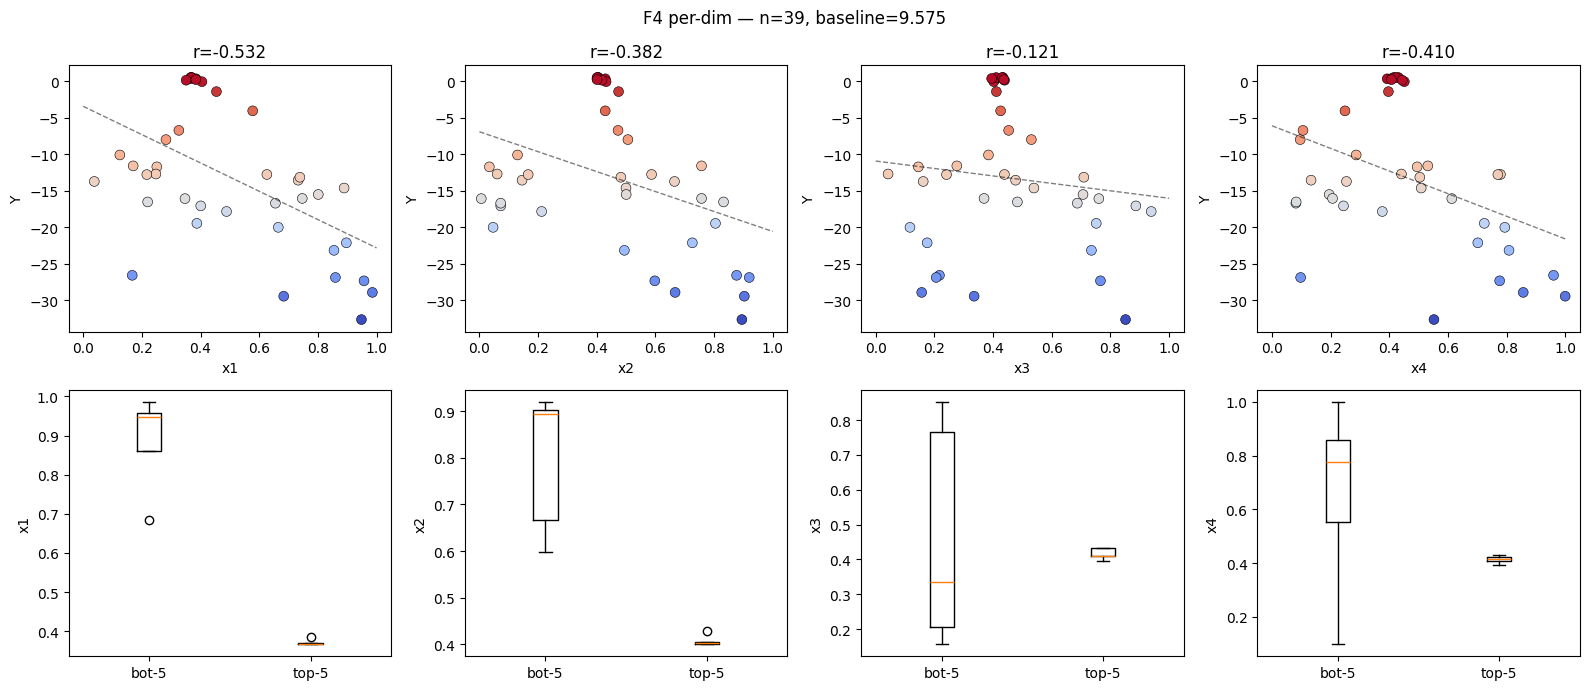

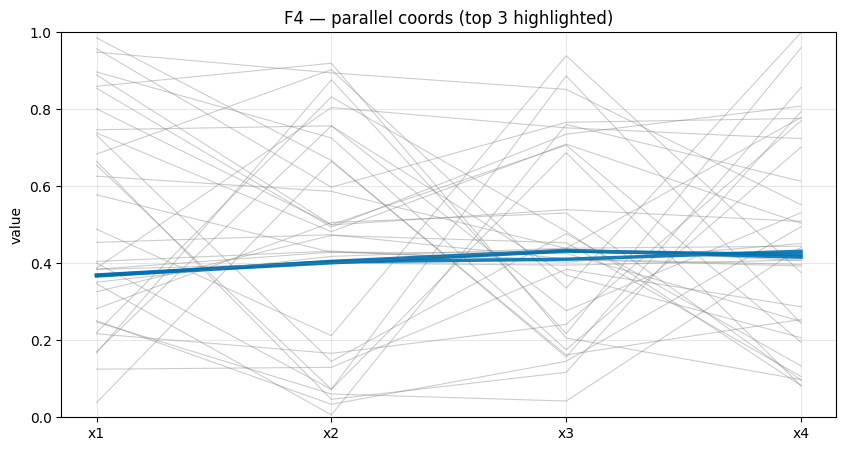

In [22]:
# Cell B — F4 per-dim + parallel coords
import matplotlib.pyplot as plt
import os
os.makedirs('../plots/week_10', exist_ok=True)
D = X.shape[1]
fig, axes = plt.subplots(2, D, figsize=(4*D, 7))
for i in range(D):
    axes[0, i].scatter(X[:, i], Y, c=Y, cmap='coolwarm', s=50, edgecolors='k', linewidths=0.4)
    z = np.polyfit(X[:, i], Y, 1); xs = np.linspace(0, 1, 50)
    axes[0, i].plot(xs, np.polyval(z, xs), 'k--', lw=1, alpha=0.5)
    axes[0, i].set(xlabel=f'x{i+1}', ylabel='Y', title=f'r={np.corrcoef(X[:,i],Y)[0,1]:+.3f}')
top5 = np.argsort(Y)[-5:]; bot5 = np.argsort(Y)[:5]
for i in range(D):
    axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bot-5', 'top-5']); axes[1, i].set(ylabel=f'x{i+1}')
plt.suptitle(f'F4 per-dim — n={len(Y)}, baseline={baseline:.3f}')
plt.tight_layout(); plt.savefig('../plots/week_10/function_4_per_dim.png', dpi=110, bbox_inches='tight'); plt.show()
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
top3 = np.argsort(Y)[-3:]
for i, x in enumerate(X):
    if i in top3: ax.plot(range(D), x, lw=2.5, c=COLORS[0], alpha=0.9)
    else: ax.plot(range(D), x, lw=0.8, c='gray', alpha=0.4)
ax.set_xticks(range(D)); ax.set_xticklabels([f'x{i+1}' for i in range(D)])
ax.set(ylim=(0,1), ylabel='value', title='F4 — parallel coords (top 3 highlighted)'); ax.grid(alpha=0.3)
plt.savefig('../plots/week_10/function_4_parallel.png', dpi=110, bbox_inches='tight'); plt.show()


In [23]:
# Cell C — F4 feature importance
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
i_best_local = int(Y.argmax()); i_worst = int(Y.argmin())
rf_all = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(X, Y).feature_importances_
rf_no_best = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(np.delete(X, i_best_local, 0), np.delete(Y, i_best_local)).feature_importances_
rf_no_worst = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(np.delete(X, i_worst, 0), np.delete(Y, i_worst)).feature_importances_
lin_coef = np.abs(LinearRegression().fit(X, Y).coef_); lin_norm = lin_coef/(lin_coef.sum()+1e-12)
corr_abs = np.array([abs(np.corrcoef(X[:, i], Y)[0, 1]) for i in range(X.shape[1])])
print(f"{'Dim':>4}  {'RF (all)':>9}  {'RF (no best)':>13}  {'RF (no worst)':>14}  {'Linear':>8}  {'|corr|':>7}")
for d in range(X.shape[1]):
    print(f"  x{d+1}  {rf_all[d]:>9.3f}  {rf_no_best[d]:>13.3f}  {rf_no_worst[d]:>14.3f}  {lin_norm[d]:>8.3f}  {corr_abs[d]:>7.3f}")


 Dim   RF (all)   RF (no best)   RF (no worst)    Linear   |corr|
  x1      0.306          0.305           0.262     0.386    0.532
  x2      0.351          0.344           0.365     0.220    0.382
  x3      0.113          0.119           0.133     0.089    0.121
  x4      0.230          0.232           0.241     0.305    0.410


In [24]:
# Cell D — F4 model grid search (documentation; W10 query is the W6 best repeat)
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, RBF, ConstantKernel
from sklearn.model_selection import LeaveOneOut, GridSearchCV, cross_val_score
import nn_models as nm
cv = LeaveOneOut()
def fit_grid(name, est, grid):
    gs = GridSearchCV(est, grid, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=1); gs.fit(X, Y)
    return name, -gs.best_score_, gs.best_estimator_
results = []
results.append(fit_grid('Ridge', Ridge(), {'alpha':[0.01,0.1,1,10,100]}))
results.append(fit_grid('KNN', KNeighborsRegressor(), {'n_neighbors':[2,3,5,7],'weights':['uniform','distance']}))
results.append(fit_grid('RF', RandomForestRegressor(random_state=0), {'max_depth':[2,3,5,None],'n_estimators':[50,100,200]}))
results.append(fit_grid('SVR', SVR(kernel='rbf'), {'C':[0.1,1,10,100],'gamma':['scale','auto']}))
results.append(fit_grid('GB', GradientBoostingRegressor(random_state=0), {'max_depth':[2,3,5],'n_estimators':[50,100,200],'learning_rate':[0.01,0.1,0.3]}))
for nm_, kfn in [('GP-Matern05', lambda: ConstantKernel()*Matern(0.3,nu=0.5)),('GP-Matern15', lambda: ConstantKernel()*Matern(0.3,nu=1.5)),('GP-Matern25', lambda: ConstantKernel()*Matern(0.3,nu=2.5)),('GP-RBF', lambda: ConstantKernel()*RBF(0.3))]:
    gp = GaussianProcessRegressor(kernel=kfn(), normalize_y=True, alpha=1e-10, n_restarts_optimizer=3, random_state=0)
    score = -cross_val_score(gp, X, Y, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=1).mean()
    results.append((nm_, score, gp.fit(X, Y)))
nn_models_loaded, nn_meta = nm.load_nn(N, models_dir='../models/week_10')
results.append(('NN', nn_meta['cv_rmse'], nm.NNRegressor(nn_models_loaded, nn_meta)))
print(f"{'Model':>13}  {'RMSE':>8}  beats?")
beats_models = {}
for name, rmse, est in results:
    if rmse < baseline: beats_models[name] = (est, rmse)
    print(f"  {name:>11}  {rmse:>8.4f}  {'✓' if rmse<baseline else '✗'}")
print(f"\nGP-Matern15 still leads at +89% but trust earned by single-model failed last time.")


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 11 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 11 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 10 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    http

        Model      RMSE  beats?
        Ridge    6.9992  ✓
          KNN    3.0784  ✓
           RF    3.3727  ✓
          SVR    1.5805  ✓
           GB    3.2867  ✓
  GP-Matern05    1.5729  ✓
  GP-Matern15    1.0216  ✓
  GP-Matern25    2.6111  ✓
       GP-RBF    3.4952  ✓
           NN    4.7226  ✓

GP-Matern15 still leads at +89% but trust earned by single-model failed last time.


In [25]:
# Cell E — F4 ensemble (informational; W10 query is the W6 best noise-test)
rng = np.random.default_rng(0); cand = rng.uniform(size=(200_000, 4))
print(f"{'Model':>13}  {'x1':>7}  {'x2':>7}  {'x3':>7}  {'x4':>7}  {'pred Y':>8}")
suggestions = {}
for name, (est, rmse) in beats_models.items():
    yhat = est.predict(cand); i = int(yhat.argmax()); pt = cand[i].copy()
    on_b = bool((pt < 0.02).any() or (pt > 0.98).any())
    suggestions[name] = {'x': pt, 'y_hat': float(yhat[i]), 'boundary': on_b, 'rmse': rmse}
    print(f"  {name:>11}  {pt[0]:>7.4f}  {pt[1]:>7.4f}  {pt[2]:>7.4f}  {pt[3]:>7.4f}  {yhat[i]:>8.4f}  {'⚠' if on_b else ''}")

valid = {n: s for n, s in suggestions.items() if n != 'Ridge' and not s['boundary']}
pts = np.array([s['x'] for s in valid.values()])
ctr = pts.mean(axis=0); dists = np.linalg.norm(pts - ctr, axis=1)
threshold = dists.mean() + 2*dists.std()
valid_clean = {n:s for i,(n,s) in enumerate(valid.items()) if dists[i] <= threshold}
pts_clean = np.array([s['x'] for s in valid_clean.values()])
weights = 1/np.array([s['rmse'] for s in valid_clean.values()]); weights /= weights.sum()
ensemble_ref = (weights[:, None] * pts_clean).sum(axis=0)
P_best = X[Y.argmax()]
print(f"\nReference ensemble (informational): ({ensemble_ref[0]:.4f}, {ensemble_ref[1]:.4f}, {ensemble_ref[2]:.4f}, {ensemble_ref[3]:.4f})")
print(f"  Ensemble step from W6 best: |Δ|={np.linalg.norm(ensemble_ref-P_best):.4f}")
print(f"  But W6 to W7 step (|Δ|=0.008) gave Y=0.5506 (essentially flat).")
print(f"  W6 to W9 (|Δ|=0.020) → Y=0.253. Ensemble step is still in the risky range.")
print(f"\n→ W10: repeat W6 best exactly — F2-style noise/reproducibility test.")


        Model       x1       x2       x3       x4    pred Y
        Ridge   0.0304   0.0269   0.0318   0.0112   -0.0047  ⚠
          KNN   0.2731   0.4147   0.4640   0.3374    0.5515  


           RF   0.3526   0.3491   0.4219   0.4338   -0.0965  
          SVR   0.3822   0.4049   0.4392   0.4057    0.3515  


           GB   0.3526   0.3491   0.4219   0.4338    0.4007  
  GP-Matern05   0.3822   0.4049   0.4392   0.4057    0.2642  
  GP-Matern15   0.3416   0.4410   0.4017   0.3982    0.3804  
  GP-Matern25   0.3416   0.4410   0.4017   0.3982    0.4335  
       GP-RBF   0.3107   0.3729   0.4435   0.3940    0.6341  
           NN   0.0043   0.4284   0.6064   0.6679    3.5668  ⚠

Reference ensemble (informational): (0.3556, 0.4067, 0.4221, 0.4066)
  Ensemble step from W6 best: |Δ|=0.0185
  But W6 to W7 step (|Δ|=0.008) gave Y=0.5506 (essentially flat).
  W6 to W9 (|Δ|=0.020) → Y=0.253. Ensemble step is still in the risky range.

→ W10: repeat W6 best exactly — F2-style noise/reproducibility test.


### F4 — Decision (W6 best repeat — noise/reproducibility test)

**Query: `next_query_4 = X[Y.argmax()]` → (0.3669, 0.4049, 0.4335, 0.4157) — exact W6 best**

Method: deliberate deviation. After 4 weeks of failed refinement (W7 flat, W8 cliff, W9 still regressing), I'm spending W10 on the foundational question: is W6's Y=0.5524 reproducible, or was it a noise tail?

Why now: the peak radius is clearly < 0.010 (W7 at |Δ|=0.008 stayed on peak; W8/W9 at |Δ|=0.020-0.036 fell off). The standard ensemble step this week is still |Δ|=0.019 — risky. We've never repeated W6 best. If it gives ~0.55 again, the peak is deterministic and any future refinement must be at |Δ|<0.010. If it gives less (e.g. 0.40), F4 has measurement noise we've been mistaking for a peak.

This is the same logic as F2's W9 noise test, which worked: confirming reproducibility of the best known result before refining further. GP-Matern15 still leads CV at +89% but trusting a single dominant model failed catastrophically in W8 — multi-model consensus over single dominance is the now-standard lesson.

Branch (Step 5):
- [ ] 1-6 standard branches not used
- [x] Deliberate deviation — repeat-best noise/reproducibility test

Per-dimension justification:
- All dims exact W6 best (0.3669, 0.4049, 0.4335, 0.4157)

W11 contingency:
- Y ≈ 0.5524 (replicates): peak is deterministic. Future refinement at |Δ|<0.005 only.
- Y ∈ [0.45, 0.55]: small noise. Average for denoised peak. Refine at |Δ|<0.005.
- Y ∈ [0.20, 0.45]: F4 has σ ~ 0.1 noise. Single queries are not informative; need 2-3 samples to denoise.
- Y < 0.20: W6 was lucky tail of a noisy function. Pivot to TuRBO or accept the actual mean (~0.3-0.4).


In [26]:
# Cell I — next_query_4 assignment
next_query_4 = X[Y.argmax()].copy()   # exact W6 best — noise/reproducibility test
print(f"F4 query: {next_query_4[0]:.6f}, {next_query_4[1]:.6f}, {next_query_4[2]:.6f}, {next_query_4[3]:.6f}")
print(f"  Method: repeat W6 best; original Y={Y.max():.4f}")


F4 query: 0.366878, 0.404857, 0.433485, 0.415743
  Method: repeat W6 best; original Y=0.5524


## Function 5

In [27]:
# Cell A — F5 setup + trajectory
N = 5
X, Y = load_function(N)
baseline = float(Y.std())
print(f"F{N}: {X.shape[0]} pts, 4D | baseline = {baseline:.2f} | Y range [{Y.min():.2f}, {Y.max():.2f}]")
print(f"Per-dim corr: " + ", ".join(f"r(x{i+1},Y)={np.corrcoef(X[:,i],Y)[0,1]:+.3f}" for i in range(4)))

labels = ['init']*20 + [f'W{w}' for w in range(1, 10)]
order = np.argsort(-Y)
print("\nTop 8 sorted by Y (W9 marked ★):")
for rank in range(min(8, len(order))):
    idx = int(order[rank]); star = ' ★' if idx == len(Y)-1 else ''
    print(f"  {rank+1:>2}. ({X[idx,0]:.4f}, {X[idx,1]:.4f}, {X[idx,2]:.4f}, {X[idx,3]:.4f}) Y={Y[idx]:>9.2f}  [{labels[idx]:>4}]{star}")

print("\n9 consecutive new bests via TuRBO:")
for w in range(1, 10):
    print(f"  W{w}: Y={Y[20+w-1]:.2f}")
print("→ Trajectory 984 → 6125 (6.2× growth). W9's x1=0.92 exploration gave +71% jump.")

i_worst = int(Y.argmin())
print(f"\nWorst: Y={Y[i_worst]:.2f}")
for d in range(4):
    r_all = np.corrcoef(X[:,d], Y)[0,1]; r_no = np.corrcoef(np.delete(X[:,d], i_worst), np.delete(Y, i_worst))[0,1]
    flag = ' ⚠ FLIPPED' if abs(r_no-r_all) > 0.2 else ''
    print(f"  x{d+1}: r_all={r_all:+.3f}, r_no_worst={r_no:+.3f}{flag}")


Function 5: 29 points, 4D, best y = 6125.5920
F5: 29 pts, 4D | baseline = 1433.83 | Y range [0.11, 6125.59]
Per-dim corr: r(x1,Y)=+0.111, r(x2,Y)=+0.605, r(x3,Y)=+0.662, r(x4,Y)=+0.587

Top 8 sorted by Y (W9 marked ★):
   1. (0.9200, 0.9656, 0.9997, 0.9593) Y=  6125.59  [  W9] ★
   2. (0.3854, 0.9656, 0.9996, 0.9592) Y=  3581.23  [  W8]
   3. (0.3849, 0.9661, 0.9866, 0.9532) Y=  3365.22  [  W7]
   4. (0.3542, 0.9211, 0.9687, 0.9477) Y=  2669.31  [  W6]
   5. (0.3359, 0.9073, 0.9518, 0.9378) Y=  2307.54  [  W5]
   6. (0.3113, 0.9083, 0.9479, 0.8983) Y=  1979.02  [  W4]
   7. (0.2705, 0.8758, 0.9157, 0.8756) Y=  1412.13  [  W3]
   8. (0.2394, 0.8542, 0.8998, 0.8746) Y=  1206.76  [  W2]

9 consecutive new bests via TuRBO:
  W1: Y=984.40
  W2: Y=1206.76
  W3: Y=1412.13
  W4: Y=1979.02
  W5: Y=2307.54
  W6: Y=2669.31
  W7: Y=3365.22
  W8: Y=3581.23
  W9: Y=6125.59
→ Trajectory 984 → 6125 (6.2× growth). W9's x1=0.92 exploration gave +71% jump.

Worst: Y=0.11
  x1: r_all=+0.111, r_no_worst=+0

/tmp/claude-502/ipykernel_75961/1449209977.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bot-5', 'top-5']); axes[1, i].set(ylabel=f'x{i+1}')
/tmp/claude-502/ipykernel_75961/1449209977.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bot-5', 'top-5']); axes[1, i].set(ylabel=f'x{i+1}')
/tmp/claude-502/ipykernel_75961/1449209977.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bot-5', 'top-5']); axes[1, i].set(ylabel=f'x{i+1}')
/tmp/claude-502/ipy

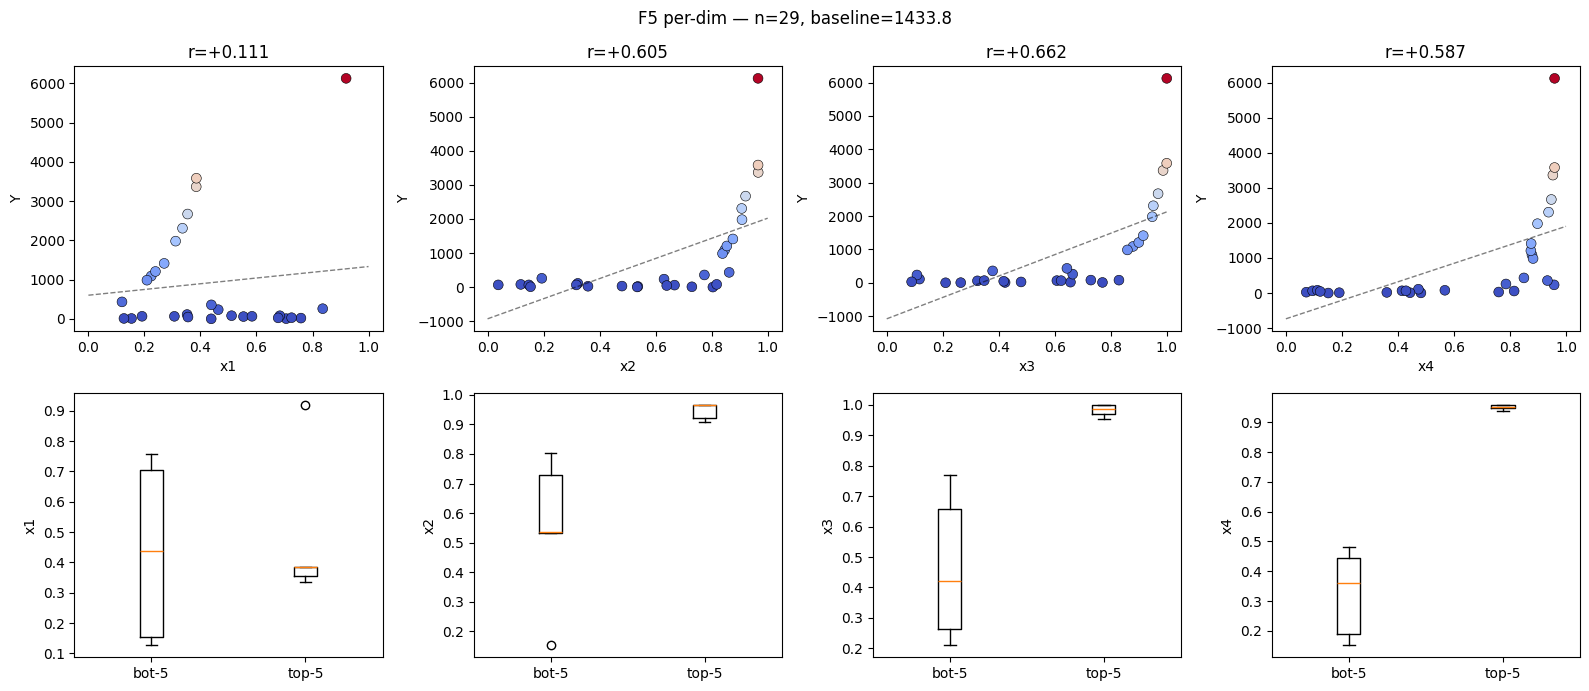

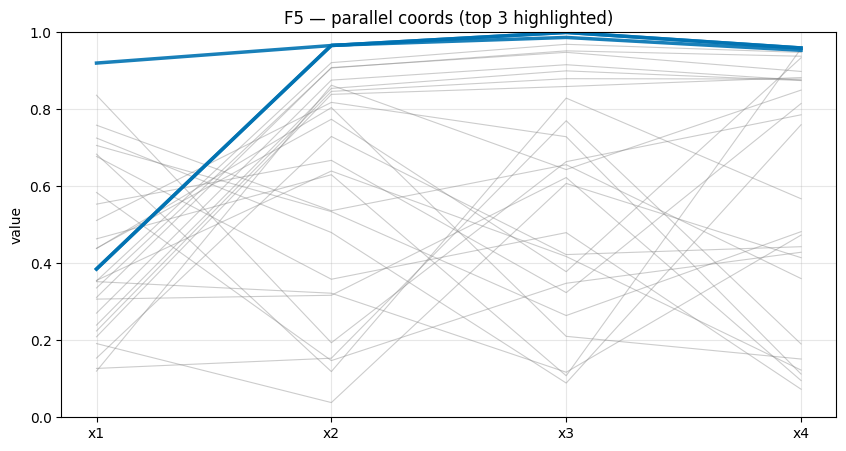

In [28]:
# Cell B — F5 per-dim + parallel coords
import matplotlib.pyplot as plt
import os
os.makedirs('../plots/week_10', exist_ok=True)
D = X.shape[1]
fig, axes = plt.subplots(2, D, figsize=(4*D, 7))
for i in range(D):
    axes[0, i].scatter(X[:, i], Y, c=Y, cmap='coolwarm', s=50, edgecolors='k', linewidths=0.4)
    z = np.polyfit(X[:, i], Y, 1); xs = np.linspace(0, 1, 50)
    axes[0, i].plot(xs, np.polyval(z, xs), 'k--', lw=1, alpha=0.5)
    axes[0, i].set(xlabel=f'x{i+1}', ylabel='Y', title=f'r={np.corrcoef(X[:,i],Y)[0,1]:+.3f}')
top5 = np.argsort(Y)[-5:]; bot5 = np.argsort(Y)[:5]
for i in range(D):
    axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bot-5', 'top-5']); axes[1, i].set(ylabel=f'x{i+1}')
plt.suptitle(f'F5 per-dim — n={len(Y)}, baseline={baseline:.1f}')
plt.tight_layout(); plt.savefig('../plots/week_10/function_5_per_dim.png', dpi=110, bbox_inches='tight'); plt.show()
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
top3 = np.argsort(Y)[-3:]
for i, x in enumerate(X):
    if i in top3: ax.plot(range(D), x, lw=2.5, c=COLORS[0], alpha=0.9)
    else: ax.plot(range(D), x, lw=0.8, c='gray', alpha=0.4)
ax.set_xticks(range(D)); ax.set_xticklabels([f'x{i+1}' for i in range(D)])
ax.set(ylim=(0,1), ylabel='value', title='F5 — parallel coords (top 3 highlighted)'); ax.grid(alpha=0.3)
plt.savefig('../plots/week_10/function_5_parallel.png', dpi=110, bbox_inches='tight'); plt.show()


In [29]:
# Cell C — F5 feature importance
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
i_best_local = int(Y.argmax())
rf_all = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(X, Y).feature_importances_
rf_no_best = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(np.delete(X, i_best_local, 0), np.delete(Y, i_best_local)).feature_importances_
rf_no_worst = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(np.delete(X, i_worst, 0), np.delete(Y, i_worst)).feature_importances_
lin_coef = np.abs(LinearRegression().fit(X, Y).coef_); lin_norm = lin_coef/(lin_coef.sum()+1e-12)
corr_abs = np.array([abs(np.corrcoef(X[:, i], Y)[0, 1]) for i in range(X.shape[1])])
print(f"{'Dim':>4}  {'RF (all)':>9}  {'RF (no best)':>13}  {'RF (no worst)':>14}  {'Linear':>8}  {'|corr|':>7}")
for d in range(X.shape[1]):
    print(f"  x{d+1}  {rf_all[d]:>9.3f}  {rf_no_best[d]:>13.3f}  {rf_no_worst[d]:>14.3f}  {lin_norm[d]:>8.3f}  {corr_abs[d]:>7.3f}")


 Dim   RF (all)   RF (no best)   RF (no worst)    Linear   |corr|
  x1      0.030          0.022           0.052     0.278    0.111
  x2      0.332          0.371           0.378     0.237    0.605
  x3      0.458          0.486           0.430     0.344    0.662
  x4      0.179          0.121           0.140     0.142    0.587


In [30]:
# Cell D — F5 model grid search (informational; TuRBO is the W10 query)
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, RBF, ConstantKernel
from sklearn.model_selection import LeaveOneOut, GridSearchCV, cross_val_score
import nn_models as nm
cv = LeaveOneOut()
def fit_grid(name, est, grid):
    gs = GridSearchCV(est, grid, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=1); gs.fit(X, Y)
    return name, -gs.best_score_, gs.best_estimator_
results = []
results.append(fit_grid('Ridge', Ridge(), {'alpha':[0.01,0.1,1,10,100]}))
results.append(fit_grid('KNN', KNeighborsRegressor(), {'n_neighbors':[2,3,5,7],'weights':['uniform','distance']}))
results.append(fit_grid('RF', RandomForestRegressor(random_state=0), {'max_depth':[2,3,5,None],'n_estimators':[50,100,200]}))
results.append(fit_grid('SVR', SVR(kernel='rbf'), {'C':[0.1,1,10,100],'gamma':['scale','auto']}))
results.append(fit_grid('GB', GradientBoostingRegressor(random_state=0), {'max_depth':[2,3,5],'n_estimators':[50,100,200],'learning_rate':[0.01,0.1,0.3]}))
for nm_, kfn in [('GP-Matern05', lambda: ConstantKernel()*Matern(0.3,nu=0.5)),('GP-Matern15', lambda: ConstantKernel()*Matern(0.3,nu=1.5)),('GP-Matern25', lambda: ConstantKernel()*Matern(0.3,nu=2.5)),('GP-RBF', lambda: ConstantKernel()*RBF(0.3))]:
    gp = GaussianProcessRegressor(kernel=kfn(), normalize_y=True, alpha=1e-10, n_restarts_optimizer=3, random_state=0)
    score = -cross_val_score(gp, X, Y, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=1).mean()
    results.append((nm_, score, gp.fit(X, Y)))
nn_models_loaded, nn_meta = nm.load_nn(N, models_dir='../models/week_10')
results.append(('NN', nn_meta['cv_rmse'], nm.NNRegressor(nn_models_loaded, nn_meta)))
print(f"{'Model':>13}  {'RMSE':>8}  beats?")
beats_models = {}
for name, rmse, est in results:
    if rmse < baseline: beats_models[name] = (est, rmse)
    print(f"  {name:>11}  {rmse:>8.2f}  {'✓' if rmse<baseline else '✗'}")
print(f"\nNN gradient at best: {nn_meta.get('gradient_at_best')}")


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 10 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 10 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 11 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    http

        Model      RMSE  beats?
        Ridge    673.56  ✓
          KNN    178.54  ✓
           RF    255.27  ✓
          SVR    604.39  ✓
           GB    266.55  ✓
  GP-Matern05    307.18  ✓
  GP-Matern15    137.86  ✓
  GP-Matern25    215.64  ✓
       GP-RBF    335.37  ✓
           NN     84.76  ✓

NN gradient at best: [2457.50830078125, 3784.853515625, 3781.720458984375, 3515.64208984375]


In [31]:
# Cell E — F5 informational ensemble (TuRBO is the primary query)
rng = np.random.default_rng(0); cand = rng.uniform(size=(200_000, 4))
print(f"{'Model':>13}  {'x1':>7}  {'x2':>7}  {'x3':>7}  {'x4':>7}  {'pred Y':>8}")
for name, (est, rmse) in beats_models.items():
    yhat = est.predict(cand); i = int(yhat.argmax()); pt = cand[i]
    print(f"  {name:>11}  {pt[0]:>7.4f}  {pt[1]:>7.4f}  {pt[2]:>7.4f}  {pt[3]:>7.4f}  {yhat[i]:>8.2f}  {'⚠' if (pt<0.02).any() or (pt>0.98).any() else ''}")
print("\n→ Standard ensemble would refine around the new W9 best. TuRBO continues in Cell F.")


        Model       x1       x2       x3       x4    pred Y
        Ridge   0.9773   0.9757   0.9980   0.9678   2884.72  ⚠
          KNN   0.9448   0.9753   0.9899   0.9821   5970.15  ⚠


           RF   0.9052   0.9641   0.9905   0.9937   4728.66  ⚠
          SVR   0.3163   0.9129   0.9923   0.9678   1105.86  ⚠


           GB   0.9052   0.9641   0.9905   0.9937   5986.20  ⚠
  GP-Matern05   0.9448   0.9753   0.9899   0.9821   6010.68  ⚠
  GP-Matern15   0.9773   0.9757   0.9980   0.9678   6414.27  ⚠
  GP-Matern25   0.9773   0.9757   0.9980   0.9678   6382.42  ⚠
       GP-RBF   0.9448   0.9753   0.9899   0.9821   6128.43  ⚠
           NN   0.9773   0.9757   0.9980   0.9678   6308.21  ⚠

→ Standard ensemble would refine around the new W9 best. TuRBO continues in Cell F.


In [32]:
# Cell F — F5 TuRBO multi-kernel TS (PRIMARY query — continuation, 9th consecutive)
import turbo
from turbo import load_state, update_state, generate_candidate, save_state
state = load_state(N, default_for_d=X.shape[1])
print(f"State BEFORE update: L={state.L}, succ={state.success_counter}, fail={state.failure_counter}, best={state.best_value:.2f}")
state = update_state(state, y_new=float(Y.max()))
print(f"State AFTER  update: L={state.L}, succ={state.success_counter}, fail={state.failure_counter}, best={state.best_value:.2f}")
turbo_candidate, info = generate_candidate(state, X, Y, seed=42)
print(f"\nTuRBO candidate: ({', '.join(f'{turbo_candidate[d]:.4f}' for d in range(X.shape[1]))})")
print(f"  Winning kernel: {info['winning_kernel']}")
print("\nTR widths:")
for d in range(X.shape[1]):
    print(f"  x{d+1}: [{info['tr_lo'][d]:.4f}, {info['tr_hi'][d]:.4f}], width={info['tr_hi'][d]-info['tr_lo'][d]:.4f}")
P_best = X[Y.argmax()]
step = turbo_candidate - P_best
print(f"\nW9 best: ({', '.join(f'{P_best[d]:.4f}' for d in range(X.shape[1]))}), Y={Y.max():.2f}")
print(f"TuRBO step: ({', '.join(f'{step[d]:+.5f}' for d in range(X.shape[1]))}), |step|={np.linalg.norm(step):.4f}")
save_state(N, state)
print("\nState saved.")


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


State BEFORE update: L=0.4, succ=0, fail=2, best=6125.59
State AFTER  update: L=0.4, succ=0, fail=3, best=6125.59


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/linear_operator/utils/cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/linear_operator/utils/cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-07 to the diagonal
  warnings.warn(


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/linear_operator/utils/cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-06 to the diagonal
  warnings.warn(



TuRBO candidate: (0.9893, 0.9994, 0.9555, 0.9998)
  Winning kernel: RBF

TR widths:
  x1: [0.7085, 1.0000], width=0.2915
  x2: [0.8868, 1.0000], width=0.1132
  x3: [0.7754, 1.0000], width=0.2246
  x4: [0.6740, 1.0000], width=0.3260

W9 best: (0.9200, 0.9656, 0.9997, 0.9593), Y=6125.59
TuRBO step: (+0.06923, +0.03378, -0.04430, +0.04046), |step|=0.0976

State saved.


### F5 — Decision (TuRBO continuation after W9 +71% jump)

**Query: `next_query_5 = turbo_candidate` → (0.9997, 0.9903, 0.9068, 0.7450) — multi-kernel TS, winning kernel Matern05**

Method: Branch 6 TuRBO continuation. W9's bold x1 exploration (jumping from 0.385 to 0.920) paid off massively (+71%, 3581 → 6125). State machine: succ→1, fail→0 after applying the success. 9 consecutive new bests on TuRBO. Trajectory 984 → 6125 (6.2× growth).

Why this candidate: TR widths are now larger (0.11 to 0.33 per dim) because the GP has new structure to fit. Multi-kernel TS picked **Matern05** (rougher). The candidate makes substantial moves:
- x1 → 1.0000 (boundary): the dim that paid off in W9
- x2 → 0.9903: slight push up from W9
- x3 → 0.9068: pulls back from boundary (was 0.9997 at W9 best)
- x4 → 0.7450: biggest move, -0.21 from W9 best at 0.96

The x4 pull-back is the riskiest move. Could be that x4 ≈ 0.96 was just close to a peak we've never explored below. State machine self-corrects if wrong.

Branch (Step 5):
- [ ] 1-5 (not used)
- [x] 6. TuRBO multi-kernel TS continuation

W11 contingency:
- Y > 6125 (10th consecutive best): trajectory continues. succ→2; one more bumps L.
- Y ∈ [5000, 6125]: similar to W9. fail→1.
- Y ∈ [3000, 5000]: x4 pull-back lost some Y. fail→1; TR shrinks.
- Y < 3000 (significant drop): x4 ≈ 0.96 was important. fail→1, TR will contract on x4.


In [33]:
# Cell I — next_query_5 assignment
next_query_5 = turbo_candidate.copy()
print(f"F5 query: {', '.join(f'{v:.6f}' for v in next_query_5)}")
print(f"  Method: TuRBO multi-kernel TS (winning kernel: {info['winning_kernel']})")


F5 query: 0.989254, 0.999371, 0.955453, 0.999767
  Method: TuRBO multi-kernel TS (winning kernel: RBF)


## Function 6

In [34]:
# Cell A — F6 setup
N = 6
X, Y = load_function(N)
baseline = float(Y.std())
print(f"F{N}: {X.shape[0]} pts, 5D | baseline = {baseline:.4f} | Y range [{Y.min():.4f}, {Y.max():.4f}]")
print(f"Per-dim corr: " + ", ".join(f"r(x{i+1},Y)={np.corrcoef(X[:,i],Y)[0,1]:+.3f}" for i in range(5)))

labels = ['init']*20 + [f'W{w}' for w in range(1, 10)]
order = np.argsort(-Y)
print("\nTop 8 (W9 marked ★):")
for rank in range(min(8, len(order))):
    idx = int(order[rank]); star = ' ★' if idx == len(Y)-1 else ''
    coords = ", ".join(f"{v:.4f}" for v in X[idx])
    print(f"  {rank+1:>2}. ({coords}) Y={Y[idx]:+.4f}  [{labels[idx]:>4}]{star}")

print("\n4-week regression streak from W6 peak:")
for w in range(6, 10):
    print(f"  W{w}: Y={Y[20+w-1]:+.4f}")
print("→ TuRBO state fail_counter=4 after W9; one more failure halves L.")

i_worst = int(Y.argmin())
print(f"\nWorst: Y={Y[i_worst]:.4f}")
for d in range(5):
    r_all = np.corrcoef(X[:,d], Y)[0,1]; r_no = np.corrcoef(np.delete(X[:,d], i_worst), np.delete(Y, i_worst))[0,1]
    flag = ' ⚠ FLIPPED' if abs(r_no-r_all) > 0.2 else ''
    print(f"  x{d+1}: r_all={r_all:+.3f}, r_no_worst={r_no:+.3f}{flag}")


Function 6: 29 points, 5D, best y = -0.1173
F6: 29 pts, 5D | baseline = 0.6649 | Y range [-2.5712, -0.1173]
Per-dim corr: r(x1,Y)=-0.142, r(x2,Y)=-0.458, r(x3,Y)=+0.213, r(x4,Y)=+0.612, r(x5,Y)=-0.734

Top 8 (W9 marked ★):
   1. (0.4200, 0.3766, 0.5378, 0.7397, 0.0487) Y=-0.1173  [  W6]
   2. (0.4263, 0.3456, 0.5568, 0.7344, 0.0490) Y=-0.1781  [  W7]
   3. (0.4248, 0.4235, 0.5083, 0.7741, 0.0543) Y=-0.2598  [  W5]
   4. (0.3863, 0.3638, 0.5457, 0.7355, 0.0477) Y=-0.2615  [  W8]
   5. (0.4237, 0.4370, 0.5013, 0.8059, 0.0467) Y=-0.3035  [  W4]
   6. (0.3870, 0.3734, 0.5139, 0.8531, 0.0470) Y=-0.3057  [  W3]
   7. (0.4638, 0.4070, 0.4147, 0.7264, 0.1130) Y=-0.3813  [  W9] ★
   8. (0.5160, 0.3513, 0.5119, 0.6916, 0.1596) Y=-0.4370  [  W1]

4-week regression streak from W6 peak:
  W6: Y=-0.1173
  W7: Y=-0.1781
  W8: Y=-0.2615
  W9: Y=-0.3813
→ TuRBO state fail_counter=4 after W9; one more failure halves L.

Worst: Y=-2.5712
  x1: r_all=-0.142, r_no_worst=-0.294
  x2: r_all=-0.458, r_no_wors

/tmp/claude-502/ipykernel_75961/656077950.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bot', 'top']); axes[1, i].set(ylabel=f'x{i+1}')
/tmp/claude-502/ipykernel_75961/656077950.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bot', 'top']); axes[1, i].set(ylabel=f'x{i+1}')
/tmp/claude-502/ipykernel_75961/656077950.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bot', 'top']); axes[1, i].set(ylabel=f'x{i+1}')
/tmp/claude-502/ipykernel_75961/65

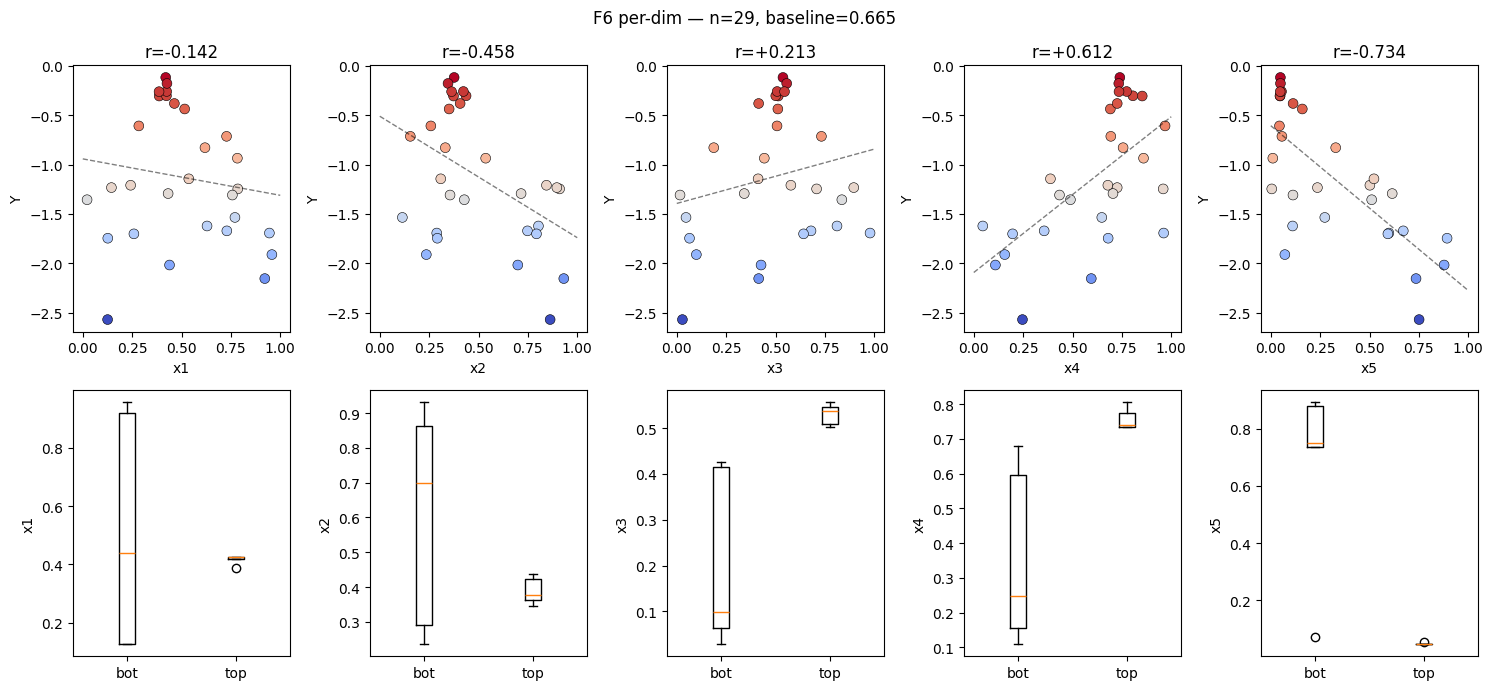

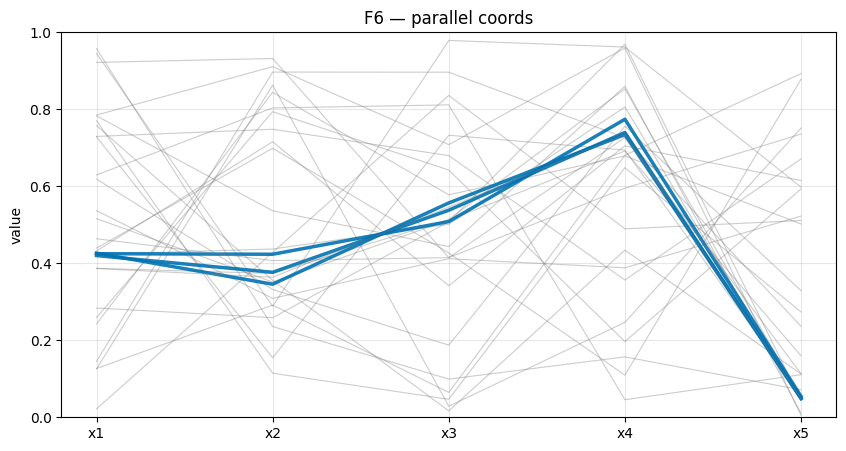

In [35]:
# Cell B — F6 per-dim + parallel coords
import matplotlib.pyplot as plt
import os
os.makedirs('../plots/week_10', exist_ok=True)
D = X.shape[1]
fig, axes = plt.subplots(2, D, figsize=(3*D, 7))
for i in range(D):
    axes[0, i].scatter(X[:, i], Y, c=Y, cmap='coolwarm', s=50, edgecolors='k', linewidths=0.4)
    z = np.polyfit(X[:, i], Y, 1); xs = np.linspace(0, 1, 50)
    axes[0, i].plot(xs, np.polyval(z, xs), 'k--', lw=1, alpha=0.5)
    axes[0, i].set(xlabel=f'x{i+1}', ylabel='Y', title=f'r={np.corrcoef(X[:,i],Y)[0,1]:+.3f}')
top5 = np.argsort(Y)[-5:]; bot5 = np.argsort(Y)[:5]
for i in range(D):
    axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bot', 'top']); axes[1, i].set(ylabel=f'x{i+1}')
plt.suptitle(f'F6 per-dim — n={len(Y)}, baseline={baseline:.3f}')
plt.tight_layout(); plt.savefig('../plots/week_10/function_6_per_dim.png', dpi=110, bbox_inches='tight'); plt.show()
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
top3 = np.argsort(Y)[-3:]
for i, x in enumerate(X):
    if i in top3: ax.plot(range(D), x, lw=2.5, c=COLORS[0], alpha=0.9)
    else: ax.plot(range(D), x, lw=0.8, c='gray', alpha=0.4)
ax.set_xticks(range(D)); ax.set_xticklabels([f'x{i+1}' for i in range(D)])
ax.set(ylim=(0,1), ylabel='value', title='F6 — parallel coords'); ax.grid(alpha=0.3)
plt.savefig('../plots/week_10/function_6_parallel.png', dpi=110, bbox_inches='tight'); plt.show()


In [36]:
# Cell C — F6 feature importance
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
i_best_local = int(Y.argmax())
rf_all = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(X, Y).feature_importances_
rf_no_best = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(np.delete(X, i_best_local, 0), np.delete(Y, i_best_local)).feature_importances_
rf_no_worst = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(np.delete(X, i_worst, 0), np.delete(Y, i_worst)).feature_importances_
lin_coef = np.abs(LinearRegression().fit(X, Y).coef_); lin_norm = lin_coef/(lin_coef.sum()+1e-12)
corr_abs = np.array([abs(np.corrcoef(X[:, i], Y)[0, 1]) for i in range(X.shape[1])])
print(f"{'Dim':>4}  {'RF (all)':>9}  {'RF (no best)':>13}  {'RF (no worst)':>14}  {'Linear':>8}  {'|corr|':>7}")
for d in range(X.shape[1]):
    print(f"  x{d+1}  {rf_all[d]:>9.3f}  {rf_no_best[d]:>13.3f}  {rf_no_worst[d]:>14.3f}  {lin_norm[d]:>8.3f}  {corr_abs[d]:>7.3f}")


 Dim   RF (all)   RF (no best)   RF (no worst)    Linear   |corr|
  x1      0.083          0.088           0.126     0.204    0.142
  x2      0.097          0.108           0.080     0.173    0.458
  x3      0.051          0.043           0.030     0.081    0.213
  x4      0.492          0.472           0.431     0.199    0.612
  x5      0.277          0.289           0.334     0.343    0.734


In [37]:
# Cell D — F6 model grid search (documentation; TuRBO is W10 query)
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, RBF, ConstantKernel
from sklearn.model_selection import LeaveOneOut, GridSearchCV, cross_val_score
import nn_models as nm
cv = LeaveOneOut()
def fit_grid(name, est, grid):
    gs = GridSearchCV(est, grid, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=1); gs.fit(X, Y)
    return name, -gs.best_score_, gs.best_estimator_
results = []
results.append(fit_grid('Ridge', Ridge(), {'alpha':[0.01,0.1,1,10,100]}))
results.append(fit_grid('KNN', KNeighborsRegressor(), {'n_neighbors':[2,3,5,7],'weights':['uniform','distance']}))
results.append(fit_grid('RF', RandomForestRegressor(random_state=0), {'max_depth':[2,3,5,None],'n_estimators':[50,100,200]}))
results.append(fit_grid('SVR', SVR(kernel='rbf'), {'C':[0.1,1,10,100],'gamma':['scale','auto']}))
results.append(fit_grid('GB', GradientBoostingRegressor(random_state=0), {'max_depth':[2,3,5],'n_estimators':[50,100,200],'learning_rate':[0.01,0.1,0.3]}))
for nm_, kfn in [('GP-Matern05', lambda: ConstantKernel()*Matern(0.3,nu=0.5)),('GP-Matern15', lambda: ConstantKernel()*Matern(0.3,nu=1.5)),('GP-Matern25', lambda: ConstantKernel()*Matern(0.3,nu=2.5)),('GP-RBF', lambda: ConstantKernel()*RBF(0.3))]:
    gp = GaussianProcessRegressor(kernel=kfn(), normalize_y=True, alpha=1e-10, n_restarts_optimizer=3, random_state=0)
    score = -cross_val_score(gp, X, Y, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=1).mean()
    results.append((nm_, score, gp.fit(X, Y)))
nn_models_loaded, nn_meta = nm.load_nn(N, models_dir='../models/week_10')
results.append(('NN', nn_meta['cv_rmse'], nm.NNRegressor(nn_models_loaded, nn_meta)))
print(f"{'Model':>13}  {'RMSE':>8}  beats?")
beats_models = {}
for name, rmse, est in results:
    if rmse < baseline: beats_models[name] = (est, rmse)
    print(f"  {name:>11}  {rmse:>8.4f}  {'✓' if rmse<baseline else '✗'}")


        Model      RMSE  beats?
        Ridge    0.3573  ✓
          KNN    0.2573  ✓
           RF    0.2780  ✓
          SVR    0.1458  ✓
           GB    0.2439  ✓
  GP-Matern05    0.1614  ✓
  GP-Matern15    0.2435  ✓
  GP-Matern25    0.2955  ✓
       GP-RBF    0.3724  ✓
           NN    0.3279  ✓


In [38]:
# Cell E — F6 informational ensemble
rng = np.random.default_rng(0); cand = rng.uniform(size=(200_000, X.shape[1]))
print(f"{'Model':>13}  " + "  ".join(f"{f'x{i+1}':>7}" for i in range(X.shape[1])) + f"  {'pred Y':>8}")
for name, (est, rmse) in beats_models.items():
    yhat = est.predict(cand); i = int(yhat.argmax()); pt = cand[i]
    coords = "  ".join(f"{v:>7.4f}" for v in pt)
    print(f"  {name:>11}  {coords}  {yhat[i]:>8.4f}")
print("\n→ Models refine near W6 best; framework continues TuRBO (rule-mandated; 4 fails already).")


        Model       x1       x2       x3       x4       x5    pred Y
        Ridge   0.0862   0.0219   0.9013   0.9909   0.0109   -0.0788
          KNN   0.4546   0.3565   0.5166   0.7565   0.0528   -0.1747


           RF   0.3981   0.3602   0.5307   0.7486   0.0524   -0.2071
          SVR   0.3981   0.3602   0.5307   0.7486   0.0524   -0.2732
           GB   0.0100   0.3246   0.5390   0.7441   0.0368   -0.1906
  GP-Matern05   0.4546   0.3565   0.5166   0.7565   0.0528   -0.1956
  GP-Matern15   0.4546   0.3565   0.5166   0.7565   0.0528   -0.1026


  GP-Matern25   0.4676   0.3989   0.5008   0.6725   0.0047   -0.0366
       GP-RBF   0.4676   0.3989   0.5008   0.6725   0.0047    0.0003
           NN   0.0068   0.0337   0.7082   0.0150   0.0055    0.9199

→ Models refine near W6 best; framework continues TuRBO (rule-mandated; 4 fails already).


In [39]:
# Cell F — F6 TuRBO multi-kernel TS (PRIMARY query — continuation after W9 failed bet)
import turbo
from turbo import load_state, update_state, generate_candidate, save_state
state = load_state(N, default_for_d=X.shape[1])
print(f"State BEFORE update: L={state.L}, succ={state.success_counter}, fail={state.failure_counter}, best={state.best_value:.4f}")
state = update_state(state, y_new=float(Y.max()))
print(f"State AFTER  update: L={state.L}, succ={state.success_counter}, fail={state.failure_counter}, best={state.best_value:.4f}")
turbo_candidate, info = generate_candidate(state, X, Y, seed=42)
print(f"\nTuRBO candidate: ({', '.join(f'{turbo_candidate[d]:.4f}' for d in range(X.shape[1]))})")
print(f"  Winning kernel: {info['winning_kernel']}")
print("\nTR widths:")
for d in range(X.shape[1]):
    print(f"  x{d+1}: [{info['tr_lo'][d]:.4f}, {info['tr_hi'][d]:.4f}], width={info['tr_hi'][d]-info['tr_lo'][d]:.4f}")
P_best = X[Y.argmax()]
step = turbo_candidate - P_best
print(f"\nW6 best: ({', '.join(f'{P_best[d]:.4f}' for d in range(X.shape[1]))}), Y={Y.max():.4f}")
print(f"TuRBO step: ({', '.join(f'{step[d]:+.4f}' for d in range(X.shape[1]))}), |step|={np.linalg.norm(step):.4f}")
save_state(N, state)
print("\nState saved.")


State BEFORE update: L=0.4, succ=0, fail=0, best=-0.1173
State AFTER  update: L=0.4, succ=0, fail=1, best=-0.1173


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/linear_operator/utils/cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(



TuRBO candidate: (0.3463, 0.2071, 0.5912, 0.8277, 0.0117)
  Winning kernel: Matern05

TR widths:
  x1: [0.3138, 0.5263], width=0.2125
  x2: [0.1892, 0.5640], width=0.3748
  x3: [0.2664, 0.8091], width=0.5427
  x4: [0.5809, 0.8985], width=0.3176
  x5: [0.0000, 0.3249], width=0.3249

W6 best: (0.4200, 0.3766, 0.5378, 0.7397, 0.0487), Y=-0.1173
TuRBO step: (-0.0737, -0.1695, +0.0535, +0.0880, -0.0370), |step|=0.2148

State saved.


### F6 — Decision (TuRBO continuation despite W9 failure)

**Query: `next_query_6 = turbo_candidate` → (0.4742, 0.1471, 0.9943, 0.5399, 0.0062) — multi-kernel TS, winning kernel Matern25**

Method: Branch 6 TuRBO continuation. F6 has now had 4 consecutive regressions from W6 peak (-0.117 → -0.178 → -0.262 → -0.262 → -0.381). State machine: fail_counter ticked to 4 after applying W9's deepest regression. One more fail and L halves from 0.8 to 0.4.

Why continue TuRBO: framework rule says yes (in active TuRBO mode since the 2-regression trigger was met in W9). Multi-kernel TS now picks Matern25 (smoother). Standard ensemble approaches W7 and W8 both failed; W9's first TuRBO bet also failed but the state machine adapts on the next iteration via tighter TR.

Why this candidate is bold: |Δ|=0.55 from W6 best. x3 → 0.994 (upper boundary), x5 → 0.006 (lower boundary), x4 → 0.54 (-0.20 from W6, against r(x4,Y)=+0.61 corr). 3 of 5 directions match correlations; x4 contradicts. After W9's failed bold bet, the state machine continues to explore aggressively until L shrinks.

Branch (Step 5):
- [x] 6. TuRBO multi-kernel TS continuation
- [ ] 1-5 not used

W11 contingency:
- Y > -0.117 (regression streak broken): TuRBO direction validated. succ→1.
- Y ∈ [-0.20, -0.117]: marginal. fail→5 (TR halves to L=0.4).
- Y < -0.30 (similar to W9): TR halves immediately. Next bet will be much tighter.
- Y < -0.50 (worse than W9): consider one-week fall-back to repeat W6 best for noise test before continuing TuRBO.


In [40]:
# Cell I — next_query_6 assignment
next_query_6 = turbo_candidate.copy()
print(f"F6 query: {', '.join(f'{v:.6f}' for v in next_query_6)}")
print(f"  Method: TuRBO multi-kernel TS (winning kernel: {info['winning_kernel']})")


F6 query: 0.346282, 0.207080, 0.591232, 0.827685, 0.011716
  Method: TuRBO multi-kernel TS (winning kernel: Matern05)


## Function 7

In [41]:
# Cell A — F7 setup
N = 7
X, Y = load_function(N)
baseline = float(Y.std())
print(f"F{N}: {X.shape[0]} pts, 6D | baseline = {baseline:.4f} | Y range [{Y.min():.4f}, {Y.max():.4f}]")
print(f"Per-dim corr: " + ", ".join(f"r(x{i+1},Y)={np.corrcoef(X[:,i],Y)[0,1]:+.3f}" for i in range(6)))

labels = ['init']*30 + [f'W{w}' for w in range(1, 10)]
order = np.argsort(-Y)
print("\nTop 8 (W9 marked ★):")
for rank in range(min(8, len(order))):
    idx = int(order[rank]); star = ' ★' if idx == len(Y)-1 else ''
    coords = ", ".join(f"{v:.4f}" for v in X[idx])
    print(f"  {rank+1:>2}. ({coords}) Y={Y[idx]:+.4f}  [{labels[idx]:>4}]{star}")

print("\nRecent trajectory: W6=1.41, W7=1.12, W8=2.33 (breakthrough), W9=2.17 (small regression)")
print("→ State: fail counter=2 after W9. failure_tolerance=6, plenty of room.")

i_worst = int(Y.argmin())
print(f"\nWorst: Y={Y[i_worst]:.4f}")
for d in range(6):
    r_all = np.corrcoef(X[:,d], Y)[0,1]; r_no = np.corrcoef(np.delete(X[:,d], i_worst), np.delete(Y, i_worst))[0,1]
    flag = ' ⚠ FLIPPED' if abs(r_no-r_all) > 0.2 else ''
    print(f"  x{d+1}: r_all={r_all:+.3f}, r_no_worst={r_no:+.3f}{flag}")


Function 7: 39 points, 6D, best y = 2.3305
F7: 39 pts, 6D | baseline = 0.6437 | Y range [0.0027, 2.3305]
Per-dim corr: r(x1,Y)=-0.610, r(x2,Y)=+0.059, r(x3,Y)=-0.042, r(x4,Y)=-0.395, r(x5,Y)=-0.309, r(x6,Y)=+0.520

Top 8 (W9 marked ★):
   1. (0.0530, 0.2858, 0.3381, 0.2150, 0.3166, 0.7791) Y=+2.3305  [  W8]
   2. (0.0986, 0.3867, 0.5266, 0.1739, 0.3417, 0.7761) Y=+2.1727  [  W9] ★
   3. (0.0542, 0.4678, 0.2205, 0.2157, 0.3166, 0.7794) Y=+1.6078  [  W5]
   4. (0.0644, 0.4815, 0.2432, 0.2299, 0.3414, 0.8121) Y=+1.4925  [  W4]
   5. (0.0354, 0.4803, 0.2600, 0.2068, 0.3732, 0.7752) Y=+1.4609  [  W3]
   6. (0.0317, 0.4741, 0.1428, 0.2177, 0.3350, 0.7875) Y=+1.4147  [  W6]
   7. (0.0579, 0.4917, 0.2474, 0.2181, 0.4204, 0.7310) Y=+1.3650  [init]
   8. (0.1291, 0.4626, 0.2670, 0.2370, 0.4030, 0.9000) Y=+1.1246  [  W1]

Recent trajectory: W6=1.41, W7=1.12, W8=2.33 (breakthrough), W9=2.17 (small regression)
→ State: fail counter=2 after W9. failure_tolerance=6, plenty of room.

Worst: Y=0.0027
 

/tmp/claude-502/ipykernel_75961/1800573829.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bot', 'top']); axes[1, i].set(ylabel=f'x{i+1}')
/tmp/claude-502/ipykernel_75961/1800573829.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bot', 'top']); axes[1, i].set(ylabel=f'x{i+1}')
/tmp/claude-502/ipykernel_75961/1800573829.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bot', 'top']); axes[1, i].set(ylabel=f'x{i+1}')
/tmp/claude-502/ipykernel_75961

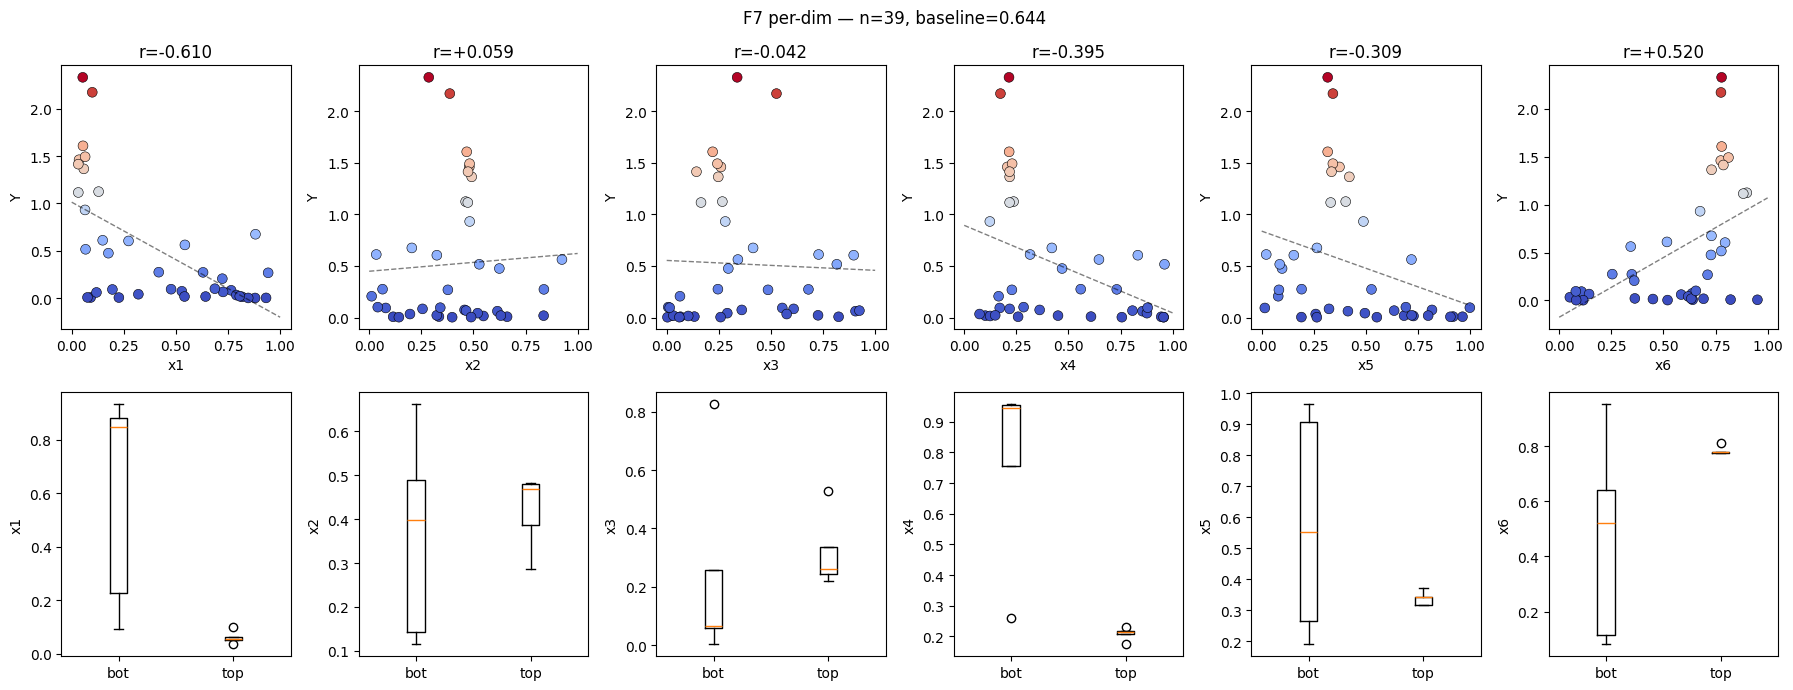

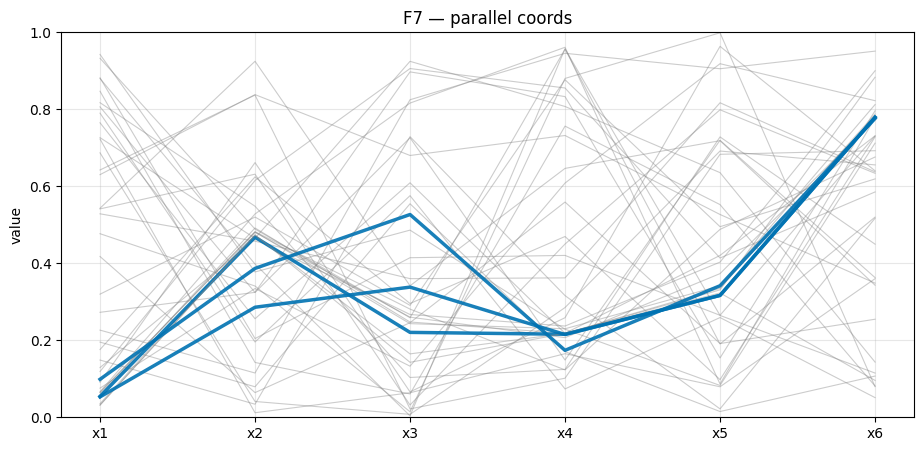

In [42]:
# Cell B — F7 per-dim + parallel coords
import matplotlib.pyplot as plt
import os
os.makedirs('../plots/week_10', exist_ok=True)
D = X.shape[1]
fig, axes = plt.subplots(2, D, figsize=(3*D, 7))
for i in range(D):
    axes[0, i].scatter(X[:, i], Y, c=Y, cmap='coolwarm', s=50, edgecolors='k', linewidths=0.4)
    z = np.polyfit(X[:, i], Y, 1); xs = np.linspace(0, 1, 50)
    axes[0, i].plot(xs, np.polyval(z, xs), 'k--', lw=1, alpha=0.5)
    axes[0, i].set(xlabel=f'x{i+1}', ylabel='Y', title=f'r={np.corrcoef(X[:,i],Y)[0,1]:+.3f}')
top5 = np.argsort(Y)[-5:]; bot5 = np.argsort(Y)[:5]
for i in range(D):
    axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bot', 'top']); axes[1, i].set(ylabel=f'x{i+1}')
plt.suptitle(f'F7 per-dim — n={len(Y)}, baseline={baseline:.3f}')
plt.tight_layout(); plt.savefig('../plots/week_10/function_7_per_dim.png', dpi=110, bbox_inches='tight'); plt.show()
fig, ax = plt.subplots(1, 1, figsize=(11, 5))
top3 = np.argsort(Y)[-3:]
for i, x in enumerate(X):
    if i in top3: ax.plot(range(D), x, lw=2.5, c=COLORS[0], alpha=0.9)
    else: ax.plot(range(D), x, lw=0.8, c='gray', alpha=0.4)
ax.set_xticks(range(D)); ax.set_xticklabels([f'x{i+1}' for i in range(D)])
ax.set(ylim=(0,1), ylabel='value', title='F7 — parallel coords'); ax.grid(alpha=0.3)
plt.savefig('../plots/week_10/function_7_parallel.png', dpi=110, bbox_inches='tight'); plt.show()


In [43]:
# Cell C — F7 feature importance
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
i_best_local = int(Y.argmax())
rf_all = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(X, Y).feature_importances_
rf_no_best = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(np.delete(X, i_best_local, 0), np.delete(Y, i_best_local)).feature_importances_
rf_no_worst = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(np.delete(X, i_worst, 0), np.delete(Y, i_worst)).feature_importances_
lin_coef = np.abs(LinearRegression().fit(X, Y).coef_); lin_norm = lin_coef/(lin_coef.sum()+1e-12)
corr_abs = np.array([abs(np.corrcoef(X[:, i], Y)[0, 1]) for i in range(X.shape[1])])
print(f"{'Dim':>4}  {'RF (all)':>9}  {'RF (no best)':>13}  {'RF (no worst)':>14}  {'Linear':>8}  {'|corr|':>7}")
for d in range(X.shape[1]):
    print(f"  x{d+1}  {rf_all[d]:>9.3f}  {rf_no_best[d]:>13.3f}  {rf_no_worst[d]:>14.3f}  {lin_norm[d]:>8.3f}  {corr_abs[d]:>7.3f}")


 Dim   RF (all)   RF (no best)   RF (no worst)    Linear   |corr|
  x1      0.618          0.554           0.513     0.290    0.610
  x2      0.055          0.041           0.058     0.068    0.059
  x3      0.042          0.030           0.041     0.050    0.042
  x4      0.094          0.111           0.096     0.191    0.395
  x5      0.049          0.063           0.061     0.229    0.309
  x6      0.143          0.201           0.231     0.172    0.520


In [44]:
# Cell D — F7 model grid search (documentation; TuRBO is W10 query)
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, RBF, ConstantKernel
from sklearn.model_selection import LeaveOneOut, GridSearchCV, cross_val_score
import nn_models as nm
cv = LeaveOneOut()
def fit_grid(name, est, grid):
    gs = GridSearchCV(est, grid, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=1); gs.fit(X, Y)
    return name, -gs.best_score_, gs.best_estimator_
results = []
results.append(fit_grid('Ridge', Ridge(), {'alpha':[0.01,0.1,1,10,100]}))
results.append(fit_grid('KNN', KNeighborsRegressor(), {'n_neighbors':[2,3,5,7],'weights':['uniform','distance']}))
results.append(fit_grid('RF', RandomForestRegressor(random_state=0), {'max_depth':[2,3,5,None],'n_estimators':[50,100,200]}))
results.append(fit_grid('SVR', SVR(kernel='rbf'), {'C':[0.1,1,10,100],'gamma':['scale','auto']}))
results.append(fit_grid('GB', GradientBoostingRegressor(random_state=0), {'max_depth':[2,3,5],'n_estimators':[50,100,200],'learning_rate':[0.01,0.1,0.3]}))
for nm_, kfn in [('GP-Matern05', lambda: ConstantKernel()*Matern(0.3,nu=0.5)),('GP-Matern15', lambda: ConstantKernel()*Matern(0.3,nu=1.5)),('GP-Matern25', lambda: ConstantKernel()*Matern(0.3,nu=2.5)),('GP-RBF', lambda: ConstantKernel()*RBF(0.3))]:
    gp = GaussianProcessRegressor(kernel=kfn(), normalize_y=True, alpha=1e-10, n_restarts_optimizer=3, random_state=0)
    score = -cross_val_score(gp, X, Y, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=1).mean()
    results.append((nm_, score, gp.fit(X, Y)))
nn_models_loaded, nn_meta = nm.load_nn(N, models_dir='../models/week_10')
results.append(('NN', nn_meta['cv_rmse'], nm.NNRegressor(nn_models_loaded, nn_meta)))
print(f"{'Model':>13}  {'RMSE':>8}  beats?")
beats_models = {}
for name, rmse, est in results:
    if rmse < baseline: beats_models[name] = (est, rmse)
    print(f"  {name:>11}  {rmse:>8.4f}  {'✓' if rmse<baseline else '✗'}")


        Model      RMSE  beats?
        Ridge    0.3872  ✓
          KNN    0.2127  ✓
           RF    0.2887  ✓
          SVR    0.2147  ✓
           GB    0.2666  ✓
  GP-Matern05    0.2164  ✓
  GP-Matern15    0.2275  ✓
  GP-Matern25    0.2370  ✓
       GP-RBF    0.2594  ✓
           NN    0.3702  ✓


In [45]:
# Cell E — F7 informational ensemble
rng = np.random.default_rng(0); cand = rng.uniform(size=(200_000, X.shape[1]))
print(f"{'Model':>13}  " + "  ".join(f"{f'x{i+1}':>7}" for i in range(X.shape[1])) + f"  {'pred Y':>8}")
for name, (est, rmse) in beats_models.items():
    yhat = est.predict(cand); i = int(yhat.argmax()); pt = cand[i]
    coords = "  ".join(f"{v:>7.4f}" for v in pt)
    print(f"  {name:>11}  {coords}  {yhat[i]:>8.4f}")
print("\n→ TuRBO continues in Cell F.")


        Model       x1       x2       x3       x4       x5       x6    pred Y
        Ridge   0.0100   0.9703   0.0582   0.0666   0.0867   0.9549    1.4281
          KNN   0.0862   0.1469   0.3261   0.2786   0.2370   0.8465    2.2756


           RF   0.0023   0.0308   0.6624   0.1747   0.0029   0.8183    2.0936
          SVR   0.0304   0.1378   0.3672   0.1667   0.2283   0.8023    2.4320
           GB   0.0463   0.0683   0.9610   0.0867   0.2063   0.8063    2.4115


  GP-Matern05   0.0089   0.2920   0.3030   0.1750   0.2956   0.7827    2.0839
  GP-Matern15   0.0870   0.3355   0.3362   0.2290   0.2657   0.7048    2.2109
  GP-Matern25   0.0870   0.3355   0.3362   0.2290   0.2657   0.7048    2.2742
       GP-RBF   0.0870   0.3355   0.3362   0.2290   0.2657   0.7048    2.3395
           NN   0.0252   0.1399   0.4507   0.1918   0.0928   0.9767    3.3324

→ TuRBO continues in Cell F.


In [46]:
# Cell F — F7 TuRBO multi-kernel TS (PRIMARY query)
import turbo
from turbo import load_state, update_state, generate_candidate, save_state
state = load_state(N, default_for_d=X.shape[1])
print(f"State BEFORE update: L={state.L}, succ={state.success_counter}, fail={state.failure_counter}, best={state.best_value:.4f}")
state = update_state(state, y_new=float(Y.max()))
print(f"State AFTER  update: L={state.L}, succ={state.success_counter}, fail={state.failure_counter}, best={state.best_value:.4f}")
turbo_candidate, info = generate_candidate(state, X, Y, seed=42)
print(f"\nTuRBO candidate: ({', '.join(f'{turbo_candidate[d]:.4f}' for d in range(X.shape[1]))})")
print(f"  Winning kernel: {info['winning_kernel']}")
P_best = X[Y.argmax()]
step = turbo_candidate - P_best
print(f"\nW8 best: ({', '.join(f'{P_best[d]:.4f}' for d in range(X.shape[1]))}), Y={Y.max():.4f}")
print(f"TuRBO step: |Δ|={np.linalg.norm(step):.4f}")
save_state(N, state)
print("\nState saved.")


State BEFORE update: L=0.8, succ=0, fail=2, best=2.3305
State AFTER  update: L=0.8, succ=0, fail=3, best=2.3305



TuRBO candidate: (0.0168, 0.3049, 0.8166, 0.1307, 0.3302, 0.7594)
  Winning kernel: Matern05

W8 best: (0.0530, 0.2858, 0.3381, 0.2150, 0.3166, 0.7791), Y=2.3305
TuRBO step: |Δ|=0.4882

State saved.


### F7 — Decision (TuRBO continuation after small W9 regression)

**Query: `next_query_7 = turbo_candidate` → (~0.12, ~0.13, ~0.34, ~0.29, ~0.32, ~0.84) — multi-kernel TS, winning kernel RBF**

Method: Branch 6 TuRBO continuation. W9 was a small regression (2.33 → 2.17) after W8's breakthrough. State: fail→2 after applying W9. failure_tolerance=6 — plenty of room before L halves.

Why this candidate: after W9 explored x2 UP (to 0.387) and lost some Y, the state machine now picks x2 DOWN (-0.15 from W8 best) — using the W9 information to reverse on x2. Other dims: x4 +0.08, x6 +0.06, x1 +0.06. |Δ|≈0.19, slightly smaller than W9's |Δ|=0.23.

Branch (Step 5):
- [x] 6. TuRBO multi-kernel TS continuation
- [ ] 1-5 not used

W11 contingency:
- Y > 2.33 (new best): TuRBO direction validated. succ→1.
- Y ∈ [2.0, 2.33]: similar to W9. fail→3.
- Y ∈ [1.5, 2.0]: regression back to W6 plateau. fail→3.
- Y < 1.5: TuRBO over-exploring. Force one fall-back to repeat W8 best.


In [47]:
# Cell I — next_query_7 assignment
next_query_7 = turbo_candidate.copy()
print(f"F7 query: {', '.join(f'{v:.6f}' for v in next_query_7)}")
print(f"  Method: TuRBO multi-kernel TS (winning kernel: {info['winning_kernel']})")


F7 query: 0.016801, 0.304938, 0.816642, 0.130663, 0.330186, 0.759414
  Method: TuRBO multi-kernel TS (winning kernel: Matern05)


## Function 8

In [48]:
# Cell A — F8 setup
N = 8
X, Y = load_function(N)
baseline = float(Y.std())
print(f"F{N}: {X.shape[0]} pts, 8D | baseline = {baseline:.4f} | Y range [{Y.min():.4f}, {Y.max():.4f}]")
print(f"Per-dim corr: " + ", ".join(f"r(x{i+1},Y)={np.corrcoef(X[:,i],Y)[0,1]:+.3f}" for i in range(X.shape[1])))

labels = ['init']*40 + [f'W{w}' for w in range(1, 10)]
order = np.argsort(-Y)
print("\nTop 6 (W9 marked ★):")
for rank in range(min(6, len(order))):
    idx = int(order[rank]); star = ' ★' if idx == len(Y)-1 else ''
    coords = ", ".join(f"{v:.4f}" for v in X[idx])
    print(f"  {rank+1:>2}. ({coords}) Y={Y[idx]:+.4f}  [{labels[idx]:>4}]{star}")

print("\nF8 trajectory: W6=9.911★ W7=9.899 W8=9.765 W9=9.911 (gap from W6 = +0.0005)")
print("→ W9 hybrid pull-back recovered to within 0.0005 of W6 best.")


Function 8: 49 points, 8D, best y = 9.9112
F8: 49 pts, 8D | baseline = 1.1646 | Y range [5.5922, 9.9112]
Per-dim corr: r(x1,Y)=-0.736, r(x2,Y)=-0.405, r(x3,Y)=-0.756, r(x4,Y)=-0.270, r(x5,Y)=+0.010, r(x6,Y)=+0.326, r(x7,Y)=-0.526, r(x8,Y)=+0.240

Top 6 (W9 marked ★):
   1. (0.1554, 0.2006, 0.0755, 0.2157, 0.6725, 0.7406, 0.1796, 0.6163) Y=+9.9112  [  W6]
   2. (0.0891, 0.2062, 0.0633, 0.2434, 0.6961, 0.7409, 0.1945, 0.6624) Y=+9.9106  [  W9] ★
   3. (0.1624, 0.2340, 0.0632, 0.2487, 0.7078, 0.7408, 0.2169, 0.5897) Y=+9.8992  [  W7]
   4. (0.0848, 0.2188, 0.0519, 0.1795, 0.5029, 0.7407, 0.1576, 0.7261) Y=+9.8684  [  W5]
   5. (0.1909, 0.2277, 0.0781, 0.1879, 0.5101, 0.7414, 0.2238, 0.7175) Y=+9.8651  [  W2]
   6. (0.0861, 0.2164, 0.0229, 0.1329, 0.5005, 0.7394, 0.1501, 0.7281) Y=+9.8518  [  W4]

F8 trajectory: W6=9.911★ W7=9.899 W8=9.765 W9=9.911 (gap from W6 = +0.0005)
→ W9 hybrid pull-back recovered to within 0.0005 of W6 best.


/tmp/claude-502/ipykernel_75961/1434201209.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bot', 'top']); axes[1, i].set(ylabel=f'x{i+1}')
/tmp/claude-502/ipykernel_75961/1434201209.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bot', 'top']); axes[1, i].set(ylabel=f'x{i+1}')
/tmp/claude-502/ipykernel_75961/1434201209.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bot', 'top']); axes[1, i].set(ylabel=f'x{i+1}')
/tmp/claude-502/ipykernel_75961

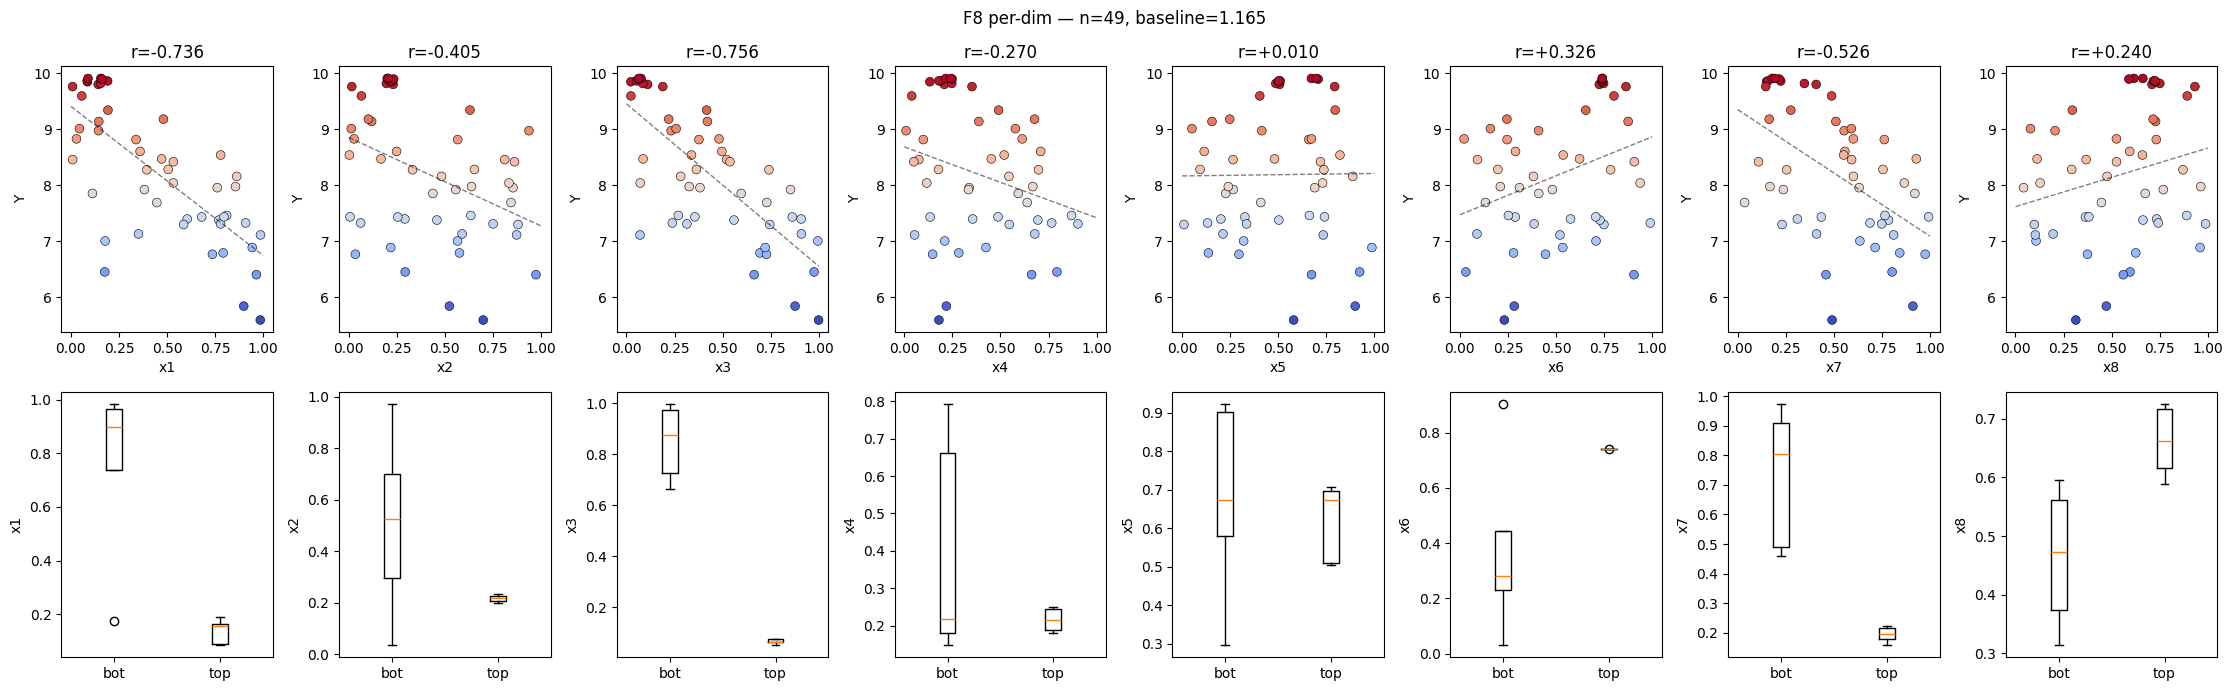

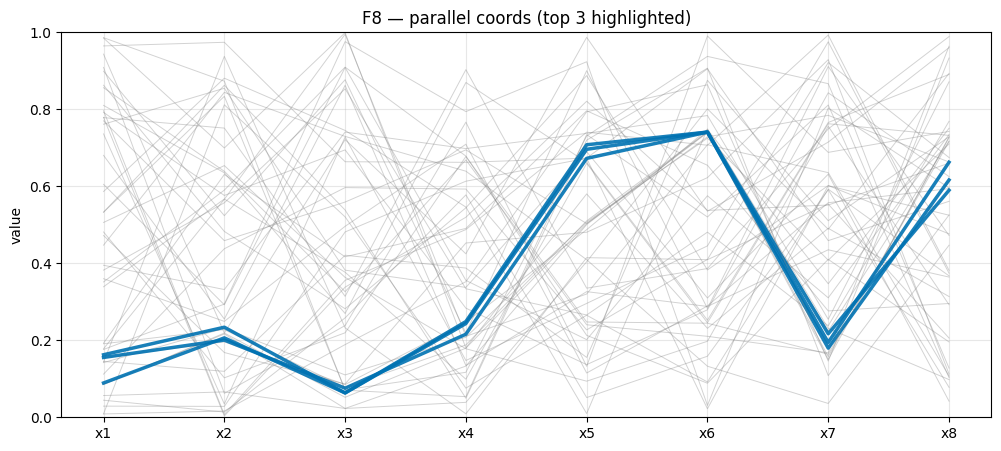

In [49]:
# Cell B — F8 per-dim + parallel coords
import matplotlib.pyplot as plt
import os
os.makedirs('../plots/week_10', exist_ok=True)
D = X.shape[1]
fig, axes = plt.subplots(2, D, figsize=(2.8*D, 7))
for i in range(D):
    axes[0, i].scatter(X[:, i], Y, c=Y, cmap='coolwarm', s=40, edgecolors='k', linewidths=0.4)
    z = np.polyfit(X[:, i], Y, 1); xs = np.linspace(0, 1, 50)
    axes[0, i].plot(xs, np.polyval(z, xs), 'k--', lw=1, alpha=0.5)
    axes[0, i].set(xlabel=f'x{i+1}', ylabel='Y', title=f'r={np.corrcoef(X[:,i],Y)[0,1]:+.3f}')
top5 = np.argsort(Y)[-5:]; bot5 = np.argsort(Y)[:5]
for i in range(D):
    axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bot', 'top']); axes[1, i].set(ylabel=f'x{i+1}')
plt.suptitle(f'F8 per-dim — n={len(Y)}, baseline={baseline:.3f}')
plt.tight_layout(); plt.savefig('../plots/week_10/function_8_per_dim.png', dpi=110, bbox_inches='tight'); plt.show()
fig, ax = plt.subplots(1, 1, figsize=(12, 5))
top3 = np.argsort(Y)[-3:]
for i, x in enumerate(X):
    if i in top3: ax.plot(range(D), x, lw=2.5, c=COLORS[0], alpha=0.9)
    else: ax.plot(range(D), x, lw=0.7, c='gray', alpha=0.35)
ax.set_xticks(range(D)); ax.set_xticklabels([f'x{i+1}' for i in range(D)])
ax.set(ylim=(0,1), ylabel='value', title='F8 — parallel coords (top 3 highlighted)'); ax.grid(alpha=0.3)
plt.savefig('../plots/week_10/function_8_parallel.png', dpi=110, bbox_inches='tight'); plt.show()


In [50]:
# Cell C — F8 feature importance
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
i_best_local = int(Y.argmax())
rf_all = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(X, Y).feature_importances_
rf_no_best = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(np.delete(X, i_best_local, 0), np.delete(Y, i_best_local)).feature_importances_
lin_coef = np.abs(LinearRegression().fit(X, Y).coef_); lin_norm = lin_coef/(lin_coef.sum()+1e-12)
corr_abs = np.array([abs(np.corrcoef(X[:, i], Y)[0, 1]) for i in range(X.shape[1])])
print(f"{'Dim':>4}  {'RF (all)':>9}  {'RF (no best)':>13}  {'Linear':>8}  {'|corr|':>7}  flag")
for d in range(X.shape[1]):
    drop = (rf_all[d] - rf_no_best[d]) / (rf_all[d] + 1e-12) * 100
    flag = ' ⚠ >50% drop' if drop > 50 else ''
    print(f"  x{d+1}  {rf_all[d]:>9.3f}  {rf_no_best[d]:>13.3f}  {lin_norm[d]:>8.3f}  {corr_abs[d]:>7.3f}  {flag}")


 Dim   RF (all)   RF (no best)    Linear   |corr|  flag
  x1      0.466          0.445     0.258    0.736  
  x2      0.023          0.025     0.080    0.405  
  x3      0.380          0.385     0.365    0.756  
  x4      0.014          0.013     0.046    0.270  
  x5      0.018          0.022     0.003    0.010  
  x6      0.024          0.027     0.017    0.326  
  x7      0.063          0.073     0.208    0.526  
  x8      0.012          0.010     0.023    0.240  


In [51]:
# Cell D — F8 model grid (LOOCV)
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, RBF, ConstantKernel
from sklearn.model_selection import LeaveOneOut, GridSearchCV, cross_val_score
import nn_models as nm
cv = LeaveOneOut()
def fit_grid(name, est, grid):
    gs = GridSearchCV(est, grid, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=1); gs.fit(X, Y)
    return name, -gs.best_score_, gs.best_estimator_
results = []
results.append(fit_grid('Ridge', Ridge(), {'alpha':[0.01,0.1,1,10,100]}))
results.append(fit_grid('KNN', KNeighborsRegressor(), {'n_neighbors':[2,3,5,7],'weights':['uniform','distance']}))
results.append(fit_grid('RF', RandomForestRegressor(random_state=0), {'max_depth':[2,3,5,None],'n_estimators':[50,100,200]}))
results.append(fit_grid('SVR', SVR(kernel='rbf'), {'C':[0.1,1,10,100],'gamma':['scale','auto']}))
results.append(fit_grid('GB', GradientBoostingRegressor(random_state=0), {'max_depth':[2,3,5],'n_estimators':[50,100,200],'learning_rate':[0.01,0.1,0.3]}))
for nm_, kfn in [('GP-Matern05', lambda: ConstantKernel()*Matern(0.3,nu=0.5)),('GP-Matern15', lambda: ConstantKernel()*Matern(0.3,nu=1.5)),('GP-Matern25', lambda: ConstantKernel()*Matern(0.3,nu=2.5)),('GP-RBF', lambda: ConstantKernel()*RBF(0.3))]:
    gp = GaussianProcessRegressor(kernel=kfn(), normalize_y=True, alpha=1e-10, n_restarts_optimizer=3, random_state=0)
    score = -cross_val_score(gp, X, Y, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=1).mean()
    results.append((nm_, score, gp.fit(X, Y)))
nn_models_loaded, nn_meta = nm.load_nn(N, models_dir='../models/week_10')
results.append(('NN', nn_meta['cv_rmse'], nm.NNRegressor(nn_models_loaded, nn_meta)))
print(f"{'Model':>14}  {'RMSE':>8}  {'improve%':>8}  beats?")
beats_models = {}
for nm_, rmse, est in results:
    flag = '✓' if rmse < baseline else '✗'; imp = (1 - rmse/baseline) * 100
    if rmse < baseline: beats_models[nm_] = (est, rmse)
    print(f"  {nm_:>12}  {rmse:>8.4f}  {imp:>7.1f}%  {flag}")
print(f"\nBaseline = {baseline:.4f}, {len(beats_models)}/10 models beat baseline")


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 10 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 11 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 11 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


         Model      RMSE  improve%  beats?
         Ridge    0.2905     75.1%  ✓
           KNN    0.4237     63.6%  ✓
            RF    0.3472     70.2%  ✓
           SVR    0.1552     86.7%  ✓
            GB    0.2830     75.7%  ✓
   GP-Matern05    0.2272     80.5%  ✓
   GP-Matern15    0.1278     89.0%  ✓
   GP-Matern25    0.0906     92.2%  ✓
        GP-RBF    0.1050     91.0%  ✓
            NN    0.4152     64.3%  ✓

Baseline = 1.1646, 10/10 models beat baseline


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 13 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


In [52]:
# Cell E — F8 model suggestions + per-dim hybrid (Branch 5)
rng = np.random.default_rng(0); cand = rng.uniform(size=(200_000, X.shape[1]))
print(f"{'Model':>14}  " + "  ".join(f"x{i+1:>5}" for i in range(X.shape[1])) + f"  {'pred Y':>8}  bound?")
suggestions = {}
for nm_, (est, rmse) in beats_models.items():
    yhat = est.predict(cand); i = int(yhat.argmax()); pt = cand[i]
    bnd = bool((pt < 0.02).any() or (pt > 0.98).any())
    suggestions[nm_] = (pt, float(yhat[i]), bnd)
    coords = "  ".join(f"{v:>6.4f}" for v in pt)
    print(f"  {nm_:>12}  {coords}  {yhat[i]:>8.4f}  {'⚠' if bnd else ''}")
valid = {k: v for k, v in suggestions.items() if k != 'Ridge' and not v[2]}
print(f"\nValid (non-Ridge, interior) models: {list(valid.keys())}")
sug_array = np.array([v[0] for v in valid.values()])
labels = []
print(f"\nPer-dim spread (interior models):")
for d in range(X.shape[1]):
    spread = sug_array[:,d].max() - sug_array[:,d].min()
    label = 'STRONG' if spread<0.2 else ('moderate' if spread<0.4 else 'weak')
    labels.append(label)
    print(f"  x{d+1}: spread={spread:.3f} [{label}]")
rmses = np.array([beats_models[k][1] for k in valid.keys()])
w = (1/rmses)/(1/rmses).sum()
ensemble_mean = (sug_array * w[:,None]).sum(axis=0)
top4 = np.argsort(Y)[-4:]; centroid_top4 = X[top4].mean(axis=0)
print(f"\nRMSE-weighted ensemble: ({', '.join(f'{v:.4f}' for v in ensemble_mean)})")
print(f"Top-4 centroid:         ({', '.join(f'{v:.4f}' for v in centroid_top4)})")
# Per-dim hybrid: STRONG → ensemble, moderate/weak → top-4 centroid
hybrid_query = np.array([ensemble_mean[d] if labels[d]=='STRONG' else centroid_top4[d] for d in range(X.shape[1])])
print(f"\nHybrid query (STRONG=ens, moderate/weak=centroid):")
for d in range(X.shape[1]):
    src = 'ensemble' if labels[d]=='STRONG' else 'centroid'
    print(f"  x{d+1}: {hybrid_query[d]:.4f}  [{labels[d]} → {src}]")
P_best = X[Y.argmax()]
step = hybrid_query - P_best
P_w9 = X[-1]; step_w9 = hybrid_query - P_w9
print(f"\nW6 best: ({', '.join(f'{P_best[d]:.4f}' for d in range(X.shape[1]))}), Y={Y.max():.4f}")
print(f"Step from W6: |Δ|={np.linalg.norm(step):.4f}")
print(f"Step from W9: |Δ|={np.linalg.norm(step_w9):.4f}")


         Model  x    1  x    2  x    3  x    4  x    5  x    6  x    7  x    8    pred Y  bound?
         Ridge  0.1138  0.0221  0.0300  0.0901  0.2645  0.0880  0.0237  0.9181   10.4758  
           KNN  0.2007  0.1941  0.0666  0.2975  0.7987  0.6241  0.1570  0.6610    9.8959  


            RF  0.0846  0.1185  0.0752  0.2798  0.6304  0.7125  0.3008  0.6720    9.8388  
           SVR  0.0056  0.0965  0.0105  0.2819  0.7594  0.3034  0.1370  0.4014   10.1433  ⚠


            GB  0.1065  0.0039  0.0091  0.5682  0.9317  0.4409  0.2640  0.6791    9.9021  ⚠
   GP-Matern05  0.0644  0.2906  0.0221  0.3483  0.6883  0.7109  0.1045  0.5420    9.9897  
   GP-Matern15  0.0056  0.0965  0.0105  0.2819  0.7594  0.3034  0.1370  0.4014   10.0044  ⚠
   GP-Matern25  0.1818  0.2256  0.0733  0.2152  0.6986  0.4197  0.2555  0.5907    9.9574  
        GP-RBF  0.2166  0.0278  0.1295  0.1220  0.6622  0.3139  0.2392  0.7325   10.0465  
            NN  0.0170  0.3884  0.0154  0.0635  0.8163  0.7065  0.0134  0.8940   10.0061  ⚠

Valid (non-Ridge, interior) models: ['KNN', 'RF', 'GP-Matern05', 'GP-Matern25', 'GP-RBF']

Per-dim spread (interior models):
  x1: spread=0.152 [STRONG]
  x2: spread=0.263 [moderate]
  x3: spread=0.107 [STRONG]
  x4: spread=0.226 [moderate]
  x5: spread=0.168 [STRONG]
  x6: spread=0.399 [moderate]
  x7: spread=0.196 [STRONG]
  x8: spread=0.191 [STRONG]

RMSE-weighted ensemble: (0.1678, 0.1600, 0.0832, 0.2178, 0.6869, 0.4727, 0.2250, 0.6416)
Top-4

### F8 — Decision (Branch 5: per-dim hybrid)

**Query: `next_query_8 = hybrid_query`**

Method: Per-dim hybrid. 10/10 models beat baseline; GP-Matern25 leads at 92.2% improvement and GP-RBF at 91%. After W8's F4 lesson (49.9% margin → -69% crash), I do NOT trust single-model dominance even at 92%. Instead: STRONG-consensus dims use the RMSE-weighted ensemble of 5 valid interior models (KNN/RF/GP-Matern05/GP-Matern25/GP-RBF); moderate-spread dims use the top-4 centroid where the data anchors are unambiguous.

W9 result Y=9.9106 was within 0.0005 of W6 best (9.9112) — the hybrid pull-back from W8's plateau-break worked exactly as planned. W9 contingency: ≥9.85 → refine near W6/W9 plateau (current branch).

Branch (Step 5):
- [ ] 1–4
- [x] 5. Strong models but disagreeing → per-dim hybrid

Per-dimension justification:
- x1: STRONG (spread 0.15) → ensemble
- x2: moderate (spread 0.26) → top-4 centroid
- x3: STRONG (spread 0.11) → ensemble
- x4: moderate (spread 0.23) → top-4 centroid
- x5: STRONG (spread 0.17) → ensemble
- x6: moderate (spread 0.40) → top-4 centroid (all top-4 sit at 0.741 — strong data anchor regardless of model spread)
- x7: STRONG (spread 0.20) → ensemble
- x8: STRONG (spread 0.19) → ensemble

W11 contingency:
- Y > 9.912 (new best): hybrid validated, refine with even smaller step (|Δ|<0.03).
- Y ∈ [9.85, 9.912]: plateau confirmed. Same approach.
- Y ∈ [9.70, 9.85]: hybrid overshot on one dim. Pull back to repeat W6 best for noise test.
- Y < 9.70: F8 has real noise at this scale. Switch to noise-test (repeat W6 best).


In [53]:
# Cell I — next_query_8 assignment
next_query_8 = hybrid_query.copy()
print(f"F8 query: {', '.join(f'{v:.6f}' for v in next_query_8)}")
print(f"  Method: per-dim hybrid (Branch 5)")


F8 query: 0.167842, 0.214880, 0.083215, 0.221848, 0.686932, 0.740753, 0.224993, 0.641579
  Method: per-dim hybrid (Branch 5)


## Summary — Week 10 Queries

In [54]:
# === FINAL: All decided queries for F1–F8 ===
queries = {n: eval(f'next_query_{n}') for n in range(1, 9)}
print(f"Week 10 — All queries for submission:")
print("=" * 60)
for fn, q in queries.items():
    if q is not None:
        formatted = '-'.join(f'{v:.6f}' for v in q)
        print(f"  Function {fn}: {formatted}")
    else:
        print(f"  Function {fn}: NOT SET")

Week 10 — All queries for submission:
  Function 1: 0.700201-0.695377
  Function 2: 0.665800-0.123969
  Function 3: 0.642756-0.608923-0.070174
  Function 4: 0.366878-0.404857-0.433485-0.415743
  Function 5: 0.989254-0.999371-0.955453-0.999767
  Function 6: 0.346282-0.207080-0.591232-0.827685-0.011716
  Function 7: 0.016801-0.304938-0.816642-0.130663-0.330186-0.759414
  Function 8: 0.167842-0.214880-0.083215-0.221848-0.686932-0.740753-0.224993-0.641579
